# Akylai Keyword Spotting

## 1. Загрузка и обзор данных

### 1.1 Импорт библиотек, загрузка данных

In [74]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [75]:
from datasets import load_dataset

# скачиваем готовый датасет с признаками
ds = load_dataset("aiacademy-kg/kws-dataset", split="train")
df = ds.to_pandas()

### 1.2 Знакомоство с данными

In [76]:
print(f'Количество объектов: {df.shape[0]}')
print(f'Количество признаков: {df.shape[1]}')

Количество объектов: 40000
Количество признаков: 252


In [77]:
df.head()

,mfcc0_mean,mfcc1_mean,mfcc2_mean,mfcc3_mean,mfcc4_mean,mfcc5_mean,mfcc6_mean,mfcc7_mean,mfcc8_mean,mfcc9_mean,...,rolloff_mean,rolloff_std,flatness_mean,flatness_std,zcr_mean,zcr_std,rms_mean,rms_std,label,source
0,-273.451324,96.284187,18.026369,-1.097848,8.324736,7.691666,-3.695917,2.433894,-3.863084,-3.073559,...,1328.824585,1150.067383,0.006193,0.026473,0.047718,0.045918,0.018150,0.017138,0,podcast
1,-341.157410,45.459671,12.227028,15.300383,3.477008,-0.364651,-7.796817,0.430853,-1.735492,0.514226,...,4078.125000,1908.980957,0.053631,0.072441,0.140972,0.072264,0.004496,0.006008,0,confusable
2,-323.533081,70.962425,2.423102,6.188729,-1.610534,9.301986,1.092122,7.101604,-1.281017,1.621867,...,2578.292969,1260.303833,0.015710,0.023008,0.085113,0.023866,0.015650,0.024469,1,positive
3,-323.649750,62.082249,3.619933,1.194878,0.405641,11.316395,6.951321,2.741580,3.509089,-0.079390,...,2127.551025,1098.202271,0.008955,0.008909,0.081717,0.037774,0.020866,0.035277,0,base_neg
4,-199.902832,56.086666,8.489406,11.424977,0.621029,-2.482201,-3.613277,-7.039908,1.968324,-1.638387,...,3069.496338,2324.336914,0.062663,0.095177,0.169871,0.155291,0.049730,0.031760,0,podcast


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 252 entries, mfcc0_mean to source
dtypes: float32(250), int64(1), str(1)
memory usage: 39.0 MB


In [79]:
df.isna().sum().sum()

np.int64(0)

In [80]:
df.duplicated().sum()

np.int64(9)

In [81]:
df["label"].value_counts()

label
0    30000
1    10000
Name: count, dtype: int64

In [82]:
df["source"].value_counts()

source
podcast       19371
positive      10000
base_neg       7680
confusable     2949
Name: count, dtype: int64

## 2. EDA

### 2.1 Исследование целевой переменной

In [83]:
df["label"].value_counts()

label
0    30000
1    10000
Name: count, dtype: int64

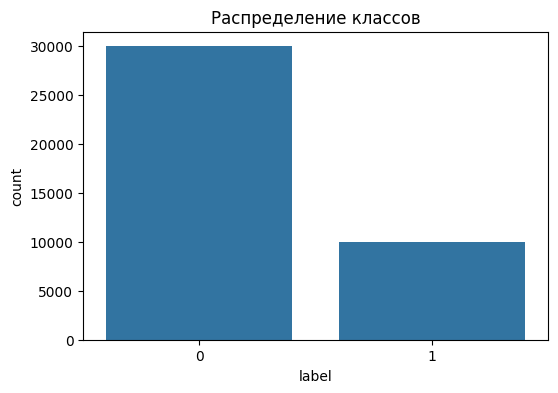

In [84]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')

plt.title("Распределение классов")
plt.show()

In [85]:
df["label"].value_counts(normalize=True) * 100

label
0    75.0
1    25.0
Name: proportion, dtype: float64

Positive класс составляет 25% выборки, negative — 75%.

Наблюдается умеренный дисбаланс классов (1:3), поэтому использование одной только accuracy может приводить к некорректной оценке качества модели.

### 2.3 Анализ источников аудио

In [86]:
df["source"].value_counts()

source
podcast       19371
positive      10000
base_neg       7680
confusable     2949
Name: count, dtype: int64

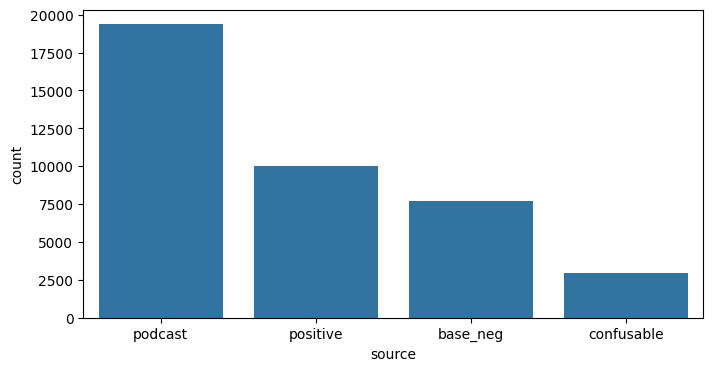

In [87]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='source', order=df['source'].value_counts().index)
plt.show()

In [88]:
df['source'].value_counts(normalize=True) * 100

source
podcast       48.4275
positive      25.0000
base_neg      19.2000
confusable     7.3725
Name: proportion, dtype: float64

Около половины данных получены из источника podcast. Особый интерес представляет категория confusable, содержащая фонетически похожие на «Акылай» слова. Несмотря на относительно небольшой объём данных, именно эта группа потенциально может оказаться наиболее сложной для классификации и стать основным источником ложных срабатываний модели.

### 2.4 Анализ распределений признаков

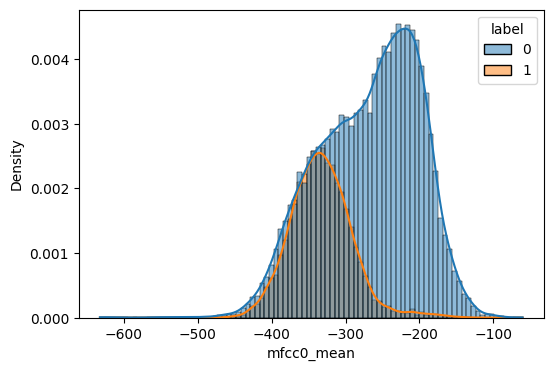

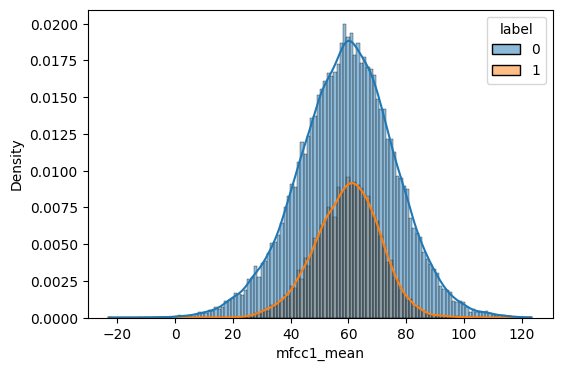

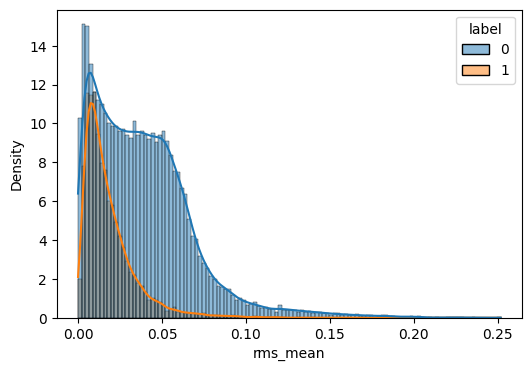

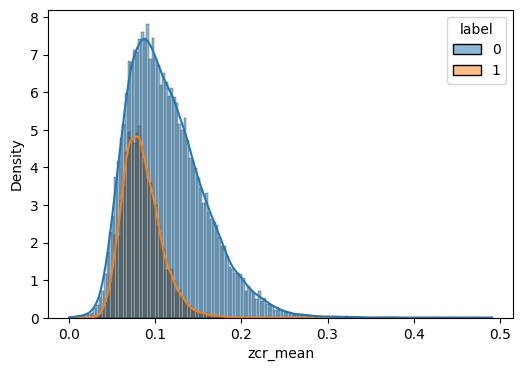

In [89]:
sample_features = [
    "mfcc0_mean",
    "mfcc1_mean",
    "rms_mean",
    "zcr_mean"
]
for col in sample_features:
    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=col,
        hue="label",
        kde=True,
        stat="density"
    )

    plt.show()

### 2.5 Корреляционный анализ

In [90]:
corr = df.drop(columns=['label', 'source']).corr().abs()

In [91]:
corr_pairs = (
    corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )  
    .stack()
    .sort_values(ascending=False)
)
corr_pairs.head(20)

mel21_mean  mel22_mean    0.994096
mel18_mean  mel19_mean    0.993691
mel22_mean  mel23_mean    0.993442
mel19_mean  mel20_mean    0.993308
mel20_mean  mel21_mean    0.992365
mel13_mean  mel14_mean    0.992266
mel14_mean  mel15_mean    0.992214
mel23_mean  mel24_mean    0.991981
mel12_mean  mel13_mean    0.991768
mel11_mean  mel12_mean    0.989991
mel26_mean  mel27_mean    0.989377
mel15_mean  mel16_mean    0.988869
mel10_mean  mel11_mean    0.988808
mel24_mean  mel25_mean    0.988649
mel27_mean  mel28_mean    0.988447
mel17_mean  mel18_mean    0.987360
mel38_mean  mel39_mean    0.987219
mel35_mean  mel36_mean    0.986962
mel7_mean   mel8_mean     0.986521
mel8_mean   mel9_mean     0.986501
dtype: float64

Корреляционный анализ показал наличие групп сильно взаимосвязанных признаков. Наиболее высокая корреляция наблюдается между соседними признаками семейства mel, значения коэффициентов корреляции достигают 0.99. Это объясняется тем, что данные признаки описывают энергии соседних частотных диапазонов аудиосигнала и поэтому содержат схожую информацию. Наличие такой зависимости может приводить к мультиколлинеарности в линейных моделях, однако для древесных алгоритмов данная особенность не является критичной.

In [92]:
corr_with_target = (
    df.drop(columns=['source'])
    .corr(numeric_only=True)['label']
    .drop('label')
    .sort_values(ascending=False)
)
corr_with_target.head(20)

contrast6_mean    0.650998
contrast6_std     0.592144
mel14_std         0.538201
mel15_std         0.523360
mel13_std         0.520519
mel12_std         0.497504
mel9_std          0.468761
mel16_std         0.467351
mel8_std          0.461463
mel11_std         0.458466
mel10_std         0.455655
mfcc5_mean        0.425035
mel7_std          0.412476
mel17_std         0.404082
mfcc7_mean        0.382602
mfcc0_std         0.370386
mel18_std         0.365496
mfcc6_mean        0.364623
mfcc3_std         0.355461
mel6_std          0.351222
Name: label, dtype: float64

Наибольшую связь с целевой переменной демонстрируют признаки семейства `contrast`, `mel` и `mfcc`.

Самыми информативными оказались `contrast6_mean` и `contrast6_std`, коэффициент корреляции которых превышает 0.59. Это свидетельствует о том, что спектральный контраст играет важную роль при распознавании ключевого слова.

Также среди наиболее значимых признаков преобладают показатели вида `*_std` (стандартные отклонения спектральных характеристик). Это говорит о том, что для классификации важна не только средняя структура спектра, но и его динамика во времени.

Появление признаков MFCC среди наиболее коррелирующих с целевой переменной соответствует их широкому использованию в задачах распознавания речи и подтверждает их информативность для задачи Keyword Spotting.

### 2.6 PCA визуализация

In [93]:
X = df.drop(columns=['source', 'label'])
X_scaled = StandardScaler().fit_transform(X)
source = df['source']

In [94]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [95]:
pca.explained_variance_ratio_

array([0.20645821, 0.11012749], dtype=float32)

In [96]:
pca.explained_variance_ratio_.sum()

np.float32(0.3165857)

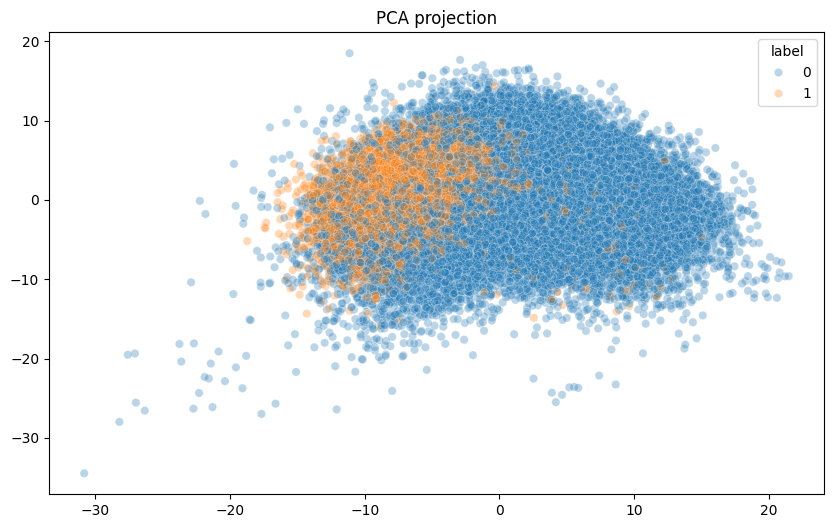

In [97]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["label"],
    alpha=0.3
)

plt.title("PCA projection")
plt.show()

Для визуализации многомерных данных был использован метод главных компонент (PCA). Первые две главные компоненты объясняют 20.65% и 11.01% дисперсии соответственно, что в сумме составляет 31.66%.

На полученной проекции наблюдается значительное перекрытие положительного и отрицательного классов, что свидетельствует о сложности задачи классификации. Вместе с тем можно заметить частичное смещение положительных объектов в область отрицательных значений первой главной компоненты, что указывает на наличие различий между классами.

Поскольку двумерная проекция сохраняет лишь около трети информации исходного пространства признаков, визуальное перекрытие классов не означает невозможность их эффективного разделения моделями машинного обучения в полном пространстве из 250 признаков.

## 3. Подготовка данных


### 3.1 Формирование матрицы признаков и целевой переменной


In [98]:
X = df.drop(columns=['source', 'label'])
y = df['label']

In [99]:
print(f'Количество объектов: {X.shape[0]}')
print(f'Количество признаков: {X.shape[1]}')
print(f'Количество классов: {y.shape}')

Количество объектов: 40000
Количество признаков: 250
Количество классов: (40000,)


Для обучения моделей была сформирована матрица признаков X размером 40000 × 250 и целевая переменная y. Колонка source была исключена из набора признаков, поскольку содержит служебную информацию об источнике аудио и может привести к утечке данных.

### 3.2 Разделение на обучающую и тестовую выборки


In [100]:
from sklearn.model_selection import train_test_split

In [101]:
X_train, X_test, y_train, y_test, source_train, source_test = train_test_split(
    X,
    y,
    source,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [102]:
print(X_train.shape)
print(X_test.shape)

(32000, 250)
(8000, 250)


In [103]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

label
0    0.75
1    0.25
Name: proportion, dtype: float64
label
0    0.75
1    0.25
Name: proportion, dtype: float64


Для оценки качества моделей данные были разделены на обучающую и тестовую выборки в соотношении 80:20. При разделении использовалась стратификация по целевой переменной, что позволило сохранить исходное распределение классов в обеих выборках.

### 3.3 Масштабирование признаков

Для линейных моделей масштабирование будет требоваться так, как линейные можели чувствительны к диапазонам значений признаков.

Для древесных моделей масштабирование не нужно так, как деревья не чувствительны к масштабу признаков

## 4. Базовая модель
Перед обучением более сложных моделей необходимо построить базовую модель. Она поможет определить минимальный уровень качества, который должна превосходить другая более сложная модель.

In [104]:
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(f"../img/{filename}", dpi=300, bbox_inches="tight")
    plt.show()

### 4.1 DummyClassifier


In [105]:
from sklearn.dummy import DummyClassifier

In [106]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)

In [107]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [108]:
print(f'accuracy_score: {accuracy_score(y_test, y_pred)}')
print(f'precision_score: {precision_score(y_test, y_pred)}')
print(f'recall_score: {recall_score(y_test, y_pred)}')
print(f'f1_score: {f1_score(y_test, y_pred)}')
print(f'roc_auc_score: {roc_auc_score(y_test, y_pred)}')
print(f'average_precision_score: {average_precision_score(y_test, y_pred)}')

accuracy_score: 0.75
precision_score: 0.0
recall_score: 0.0
f1_score: 0.0
roc_auc_score: 0.5
average_precision_score: 0.25


/Users/ainurakerimkulova/Documents/Data Scince/ kws-project/kws-project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


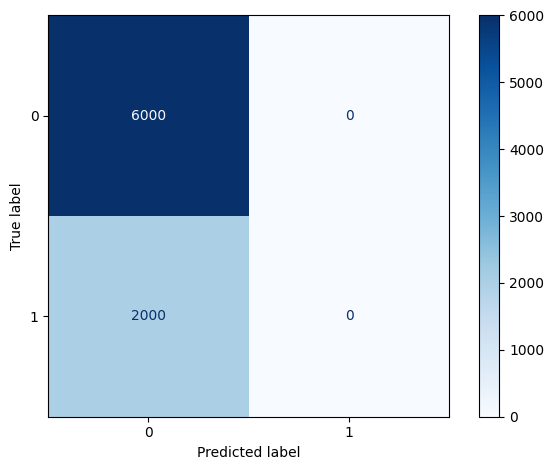

In [109]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
save_plot("DC_confusion_matrix.png")

### 4.2 Анализ результатов baseline

Базовая модель `DummyClassifier` со стратегией `most_frequent` всегда предсказывает наиболее часто встречающийся класс — отрицательный (`label = 0`).

Несмотря на то что accuracy составляет около 75%, модель полностью игнорирует положительный класс. В результате значения Precision, Recall и F1-score для класса `label = 1` равны нулю.

Полученный результат демонстрирует, что при наличии дисбаланса классов метрика Accuracy не отражает реальное качество модели. Для дальнейшего сравнения моделей целесообразно использовать также Precision, Recall, F1-score, ROC-AUC.

## 5. Линейные модели

На следующем этапе исследования рассматриваются линейные модели классификации. Они являются хорошей отправной точкой благодаря простоте интерпретации, высокой скорости обучения и хорошей работе на задачах бинарной классификации.

Поскольку признаки имеют различные диапазоны значений, перед обучением линейных моделей выполняется их масштабирование с помощью StandardScaler.

### 5.1 Масштабирование признаков

In [110]:
from sklearn.preprocessing import StandardScaler

In [111]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5.2 Logistic Regression

#### 5.2.1 Базовая модель

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [113]:
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=2000))
])
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

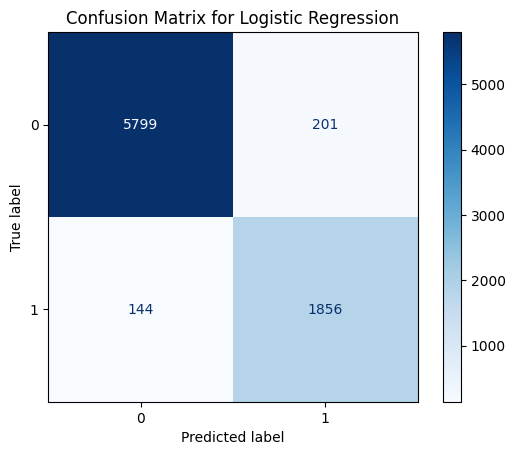

In [114]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

Матрица ошибок показывает, что логистическая регрессия корректно классифицирует большинство объектов обоих классов. Из 6000 отрицательных примеров модель ошибочно классифицировала как положительные только 201 запись (False Positive), что свидетельствует о низком количестве ложных срабатываний. Из 2000 положительных примеров модель пропустила 144 записи (False Negative), правильно обнаружив ключевое слово в 1856 случаях. Количество ложных срабатываний и пропусков относительно невелико, что подтверждается высокими значениями Precision (90.2%) и Recall (92.8%). В целом матрица ошибок демонстрирует хорошую способность модели распознавать ключевое слово при сохранении низкого уровня ошибочных активаций.

<Axes: ylabel='Count'>

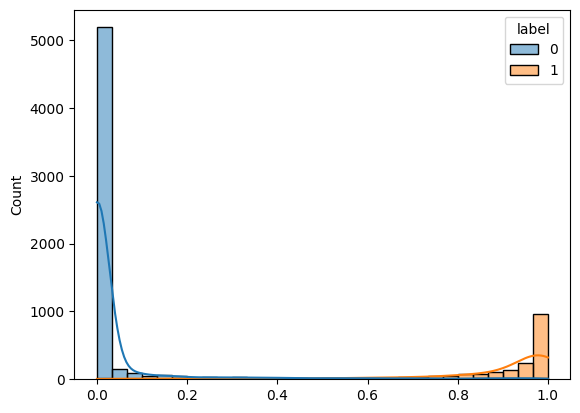

In [115]:
import seaborn as sns

sns.histplot(
    x=y_pred_proba,
    hue=y_test,
    bins=30,
    kde=True
)

Гистограмма распределения предсказанных вероятностей показывает, что логистическая регрессия хорошо разделяет объекты двух классов. Для большинства отрицательных примеров модель присваивает вероятности, близкие к 0, тогда как положительные примеры получают вероятности, близкие к 1. Между распределениями наблюдается лишь небольшое перекрытие, что свидетельствует о высокой уверенности модели в большинстве предсказаний. Небольшое число объектов с промежуточными вероятностями соответствует случаям, в которых возникают ложные срабатывания и пропуски. Полученный результат объясняет высокие значения ROC-AUC и PR-AUC и указывает на возможность дополнительной оптимизации рабочего порога классификации.

#### 5.2.2 Подбор гиперпараметров

In [116]:
from sklearn.model_selection import GridSearchCV

In [117]:
log_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(solver='liblinear', random_state=42, max_iter=3000))
])
param_grid = [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": np.logspace(-3, 2, 10),
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": np.logspace(-3, 2, 10),
        "model__class_weight": [None, "balanced"]
    }
]
grid_log_reg = GridSearchCV(
    estimator=log_reg_pipe,
    param_grid=param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


/Users/ainurakerimkulova/Documents/Data Scince/ kws-project/kws-project/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ainurakerimkulova/Documents/Data Scince/ kws-project/kws-project/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='el

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': array([1.0000...00000000e+02]), 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}, {'model__C': array([1.0000...00000000e+02]), 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l2'], 'model__solver': ['lbfgs']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be ava

In [118]:
print(f"Best parameters: {grid_log_reg.best_params_}")
print(f"Best average precision score: {grid_log_reg.best_score_}")

Best parameters: {'model__C': np.float64(2.1544346900318843), 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best average precision score: 0.965309429751261


Для поиска оптимальной конфигурации логистической регрессии был использован метод **GridSearchCV** с **5-блочной кросс-валидацией** (`cv=5`).

В качестве целевой метрики оптимизации была выбрана **Average Precision (AP)**, поскольку задача характеризуется дисбалансом классов, а данная метрика более информативна, чем Accuracy.

В ходе поиска подбирались следующие гиперпараметры:

- **`C`** — коэффициент, определяющий силу регуляризации;
- **`penalty`** — тип регуляризации (`L1` и `L2`);
- **`class_weight`** — использование или отсутствие компенсации дисбаланса классов;
- **`solver`** — алгоритм оптимизации модели.

#### Оптимальные гиперпараметры

| Гиперпараметр | Значение |
|---------------|----------|
| Solver | `liblinear` |
| Penalty | `L1` |
| C | **2.1544** |
| Class weight | `None` |

Среднее значение метрики **Average Precision**, полученное по результатам 5-кратной кросс-валидации, составило:

**Average Precision = 0.9653**

#### Анализ результатов

Оптимальным алгоритмом оптимизации оказался **liblinear**, поддерживающий использование L1-регуляризации.

Выбор **L1-регуляризации** свидетельствует о том, что не все признаки одинаково информативны для решения задачи. В отличие от L2-регуляризации, L1 способна обнулять коэффициенты малозначимых признаков, автоматически выполняя их отбор и уменьшая сложность модели.

Оптимальное значение **C = 2.1544** указывает на необходимость использования умеренной регуляризации. Более сильная регуляризация приводила к ухудшению качества модели, тогда как дальнейшее её ослабление также не обеспечивало прироста качества.

Интересным результатом является выбор **`class_weight=None`**. Несмотря на наличие дисбаланса классов, автоматическое увеличение весов положительного класса не улучшило качество модели. Это говорит о том, что исходное распределение признаков уже позволяет логистической регрессии эффективно разделять классы без дополнительной компенсации дисбаланса.

Полученное значение **Average Precision = 0.9653** подтверждает высокую устойчивость модели. Поскольку данная оценка была получена с использованием кросс-валидации, можно сделать вывод, что найденная конфигурация гиперпараметров хорошо обобщается на различных разбиениях обучающей выборки и не является результатом случайного удачного разделения данных.

In [119]:
best_model = grid_log_reg.best_estimator_
y_pred_lr = best_model.predict(X_test)
y_proba_lr = best_model.predict_proba(X_test)[:, 1]

In [120]:
from sklearn.metrics import log_loss

In [121]:
results = []

results.append({
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr),
    "roc_auc": roc_auc_score(y_test, y_proba_lr),
    "pr_auc": average_precision_score(y_test, y_proba_lr ),
    "log_loss": log_loss(y_test, y_proba_lr)
})

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss
0,Logistic Regression,0.957625,0.904924,0.928,0.916317,0.98966,0.966675,0.111815


In [122]:

print("accuracy", f"{accuracy_score(y_test, y_pred_lr):.4f}")
print("precision", f"{precision_score(y_test, y_pred_lr):.4f}")
print("recall", f"{recall_score(y_test, y_pred_lr):.4f}")
print("f1", f"{f1_score(y_test, y_pred_lr):.4f}")
print("roc_auc", f"{roc_auc_score(y_test, y_proba_lr):.4f}")
print("pr_auc", f"{average_precision_score(y_test, y_proba_lr):.4f}")
print("log_loss", f"{log_loss(y_test, y_proba_lr):.4f}")

accuracy 0.9576
precision 0.9049
recall 0.9280
f1 0.9163
roc_auc 0.9897
pr_auc 0.9667
log_loss 0.1118


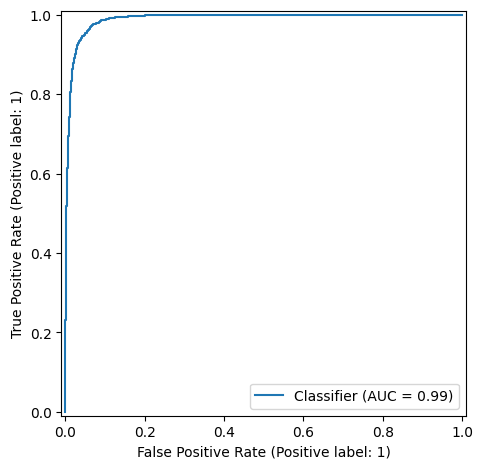

In [123]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba_lr)
save_plot("LR_roc_curve")
plt.show()

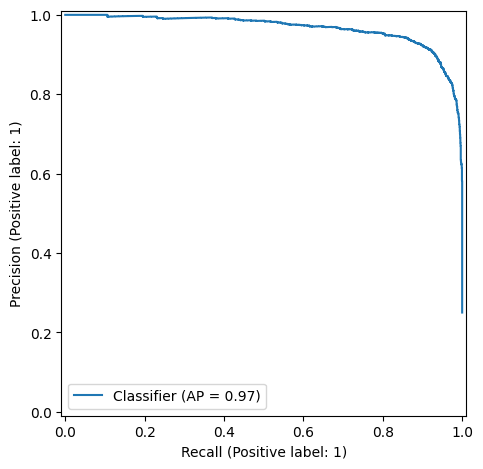

In [124]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr)
save_plot("LR_pr_curve.png")
plt.show()


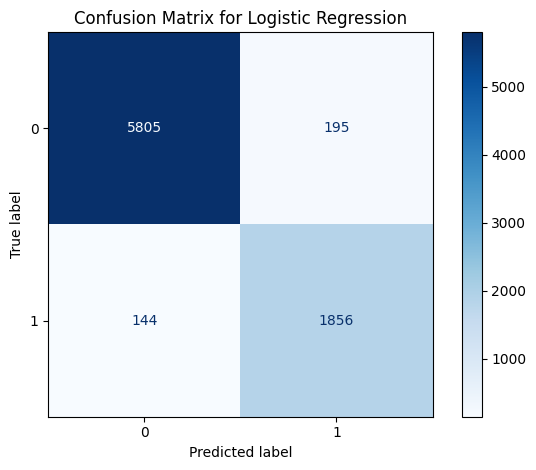

In [125]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Logistic Regression")
save_plot("LR_confusion_matrix.png")
plt.show()

Подбор гиперпараметров не привёл к существенному улучшению качества модели. Наблюдается лишь небольшое увеличение Accuracy, Precision и F1-score, тогда как значения Recall, ROC-AUC и PR-AUC практически не изменились.

Это говорит о том, что уже базовая конфигурация логистической регрессии была близка к оптимальной для данной задачи. Подбор гиперпараметров подтвердил это предположение и позволил найти конфигурацию, обеспечивающую лишь незначительный прирост качества.

#### 5.2.3 Анализ коэффициентов логистической регрессии

In [126]:
coef = best_model.named_steps['model'].coef_[0]
coef = pd.Series(coef, index=X.columns)
coef.sort_values(key=np.abs, ascending=False).head(20)

mfcc0_std        -3.939019
mel19_mean       -2.657118
mel26_mean       -2.293029
mel33_mean       -2.266168
mel37_mean       -2.137640
mel20_mean        2.087481
mel32_mean        2.084709
bandwidth_mean    1.938415
contrast6_mean    1.935313
mel17_mean        1.851014
d1_2_std          1.714393
mfcc1_std        -1.706071
mel39_mean       -1.655085
mel6_std          1.524039
mel38_mean        1.449084
mel23_std        -1.304509
mel2_std         -1.289808
mel16_mean       -1.240149
mel27_mean        1.176081
contrast2_mean   -1.141525
dtype: float64

In [127]:
(coef == 0).sum()

np.int64(21)

L1-регуляризация автоматически выполнила отбор признаков, обнулив коэффициенты для части спектральных характеристик. Это свидетельствует о том, что далеко не все признаки одинаково важны для распознавания ключевого слова.

### 5.3 SGDClassifier

In [128]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline

#### 5.3.1 Базовая модель

In [129]:
sgd_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SGDClassifier(
        loss="hinge",
        random_state=42,
        max_iter=3000
    ))
])
sgd_pipe.fit(X_train, y_train)
y_pred_sgd = sgd_pipe.predict(X_test)
y_scores_sgd = sgd_pipe.decision_function(X_test)

In [130]:
print(f"Accuracy : {accuracy_score(y_test, y_pred_sgd):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_sgd):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_sgd):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_sgd):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_scores_sgd):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_scores_sgd):.4f}")

Accuracy : 0.9520
Precision: 0.9012
Recall   : 0.9075
F1-score : 0.9043
ROC-AUC  : 0.9868
PR-AUC   : 0.9590


In [131]:
print(classification_report(y_test, y_pred_sgd))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      6000
           1       0.90      0.91      0.90      2000

    accuracy                           0.95      8000
   macro avg       0.94      0.94      0.94      8000
weighted avg       0.95      0.95      0.95      8000



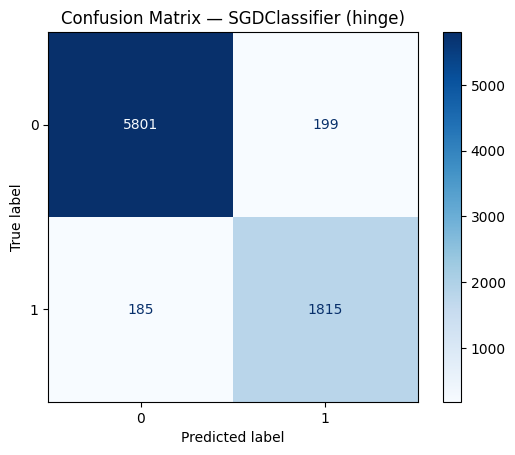

In [132]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_sgd,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix — SGDClassifier (hinge)")
plt.show()

Базовая модель SGDClassifier с функцией потерь `hinge` показала высокое качество классификации. Тем не менее по всем основным метрикам она немного уступила Logistic Regression.

Основное отличие заключается в увеличении количества ложноотрицательных классификаций (False Negative), что привело к снижению Recall и F1-score.

При этом количество ложных срабатываний (False Positive) осталось практически на том же уровне, что и у Logistic Regression.

Полученные результаты свидетельствуют о том, что для рассматриваемого набора признаков логистическая регрессия обеспечивает более качественное разделение классов.

#### 5.3.2 Подбор гиперпараметров

In [133]:
sgd_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SGDClassifier(
        loss="hinge",
        random_state=42
    ))
])
param_grid = {
    "model__alpha": np.logspace(-6, -2, 8),
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__class_weight": [None, "balanced"],
    "model__max_iter": [2000, 5000]
}

In [134]:
grid_sgd = GridSearchCV(
    estimator=sgd_pipe,
    param_grid=param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_sgd.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': array([1.0000...00000000e-02]), 'model__class_weight': [None, 'balanced'], 'model__max_iter': [2000, 5000], 'model__penalty': ['l2', 'l1', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about mul

In [135]:
print("Best parameters:")
print(grid_sgd.best_params_)

print()

print("Best Average Precision:")
print(grid_sgd.best_score_)

Best parameters:
{'model__alpha': np.float64(1.3894954943731361e-05), 'model__class_weight': None, 'model__max_iter': 2000, 'model__penalty': 'elasticnet'}

Best Average Precision:
0.9568097950366138


In [136]:
best_sgd = grid_sgd.best_estimator_

In [137]:
y_pred_sgd = best_sgd.predict(X_test)

y_scores_sgd = best_sgd.decision_function(X_test)

In [138]:
results.append({
    "model": "SGDClassifier (tuned)",
    "accuracy": accuracy_score(y_test, y_pred_sgd),
    "precision": precision_score(y_test, y_pred_sgd),
    "recall": recall_score(y_test, y_pred_sgd),
    "f1": f1_score(y_test, y_pred_sgd),
    "roc_auc": roc_auc_score(y_test, y_scores_sgd),
    "pr_auc": average_precision_score(y_test, y_scores_sgd)
})

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss
0,Logistic Regression,0.957625,0.904924,0.9280,0.916317,0.98966,0.966675,0.111815
1,SGDClassifier (tuned),0.951875,0.905575,0.9015,0.903533,0.98698,0.956646,NaN


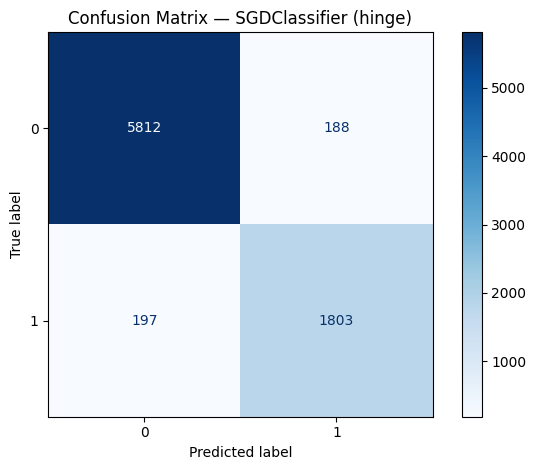

In [139]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_sgd,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix — SGDClassifier (hinge)")
save_plot("SGD_confusion_matrix.png")
plt.show()

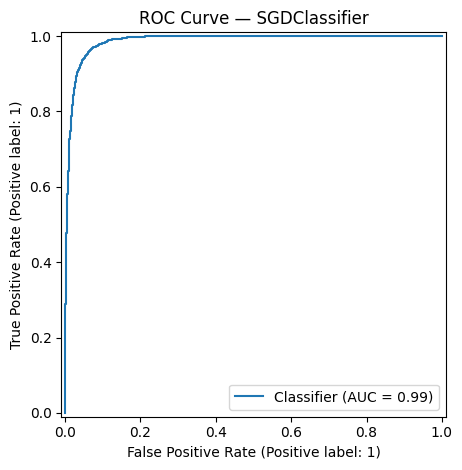

In [140]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    y_scores_sgd
)

plt.title("ROC Curve — SGDClassifier")
save_plot("SGD_roc_curve.png")
plt.show()

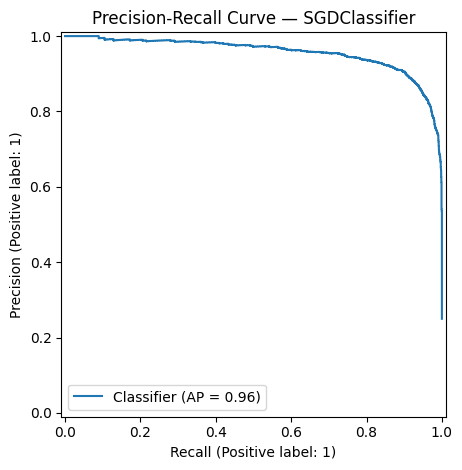

In [141]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_scores_sgd
)
plt.title("Precision-Recall Curve — SGDClassifier")
save_plot("SGD_precision_recall_curve.png")
plt.show()

ROC-кривая демонстрирует высокую способность модели разделять классы. Значение ROC-AUC составило около 0.99, однако немного уступает результату Logistic Regression.

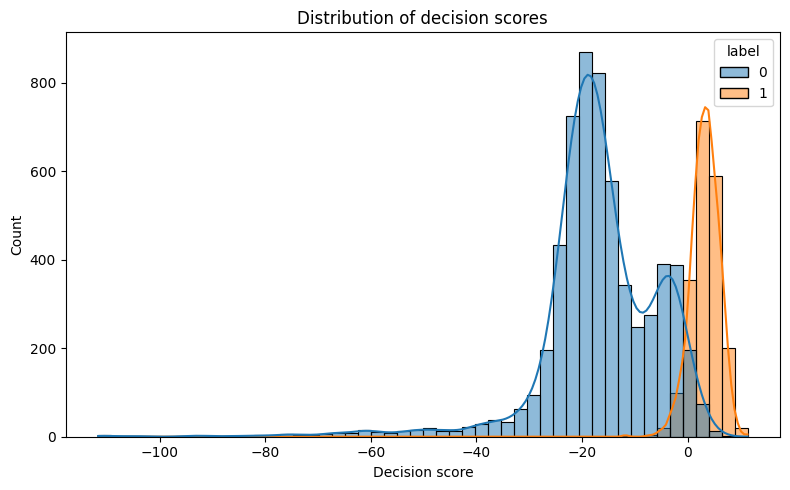

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    x=y_scores_sgd,
    hue=y_test,
    bins=50,
    kde=True,
    stat="count"
)

plt.title("Distribution of decision scores")
plt.xlabel("Decision score")
save_plot("SGD_decision_scores_distribution.png")
plt.show()

Распределения decision score для двух классов имеют небольшую область пересечения. Большинство объектов отрицательного класса имеют отрицательные значения функции решения, тогда как объекты положительного класса — положительные значения. Это свидетельствует о хорошем разделении классов линейным классификатором.

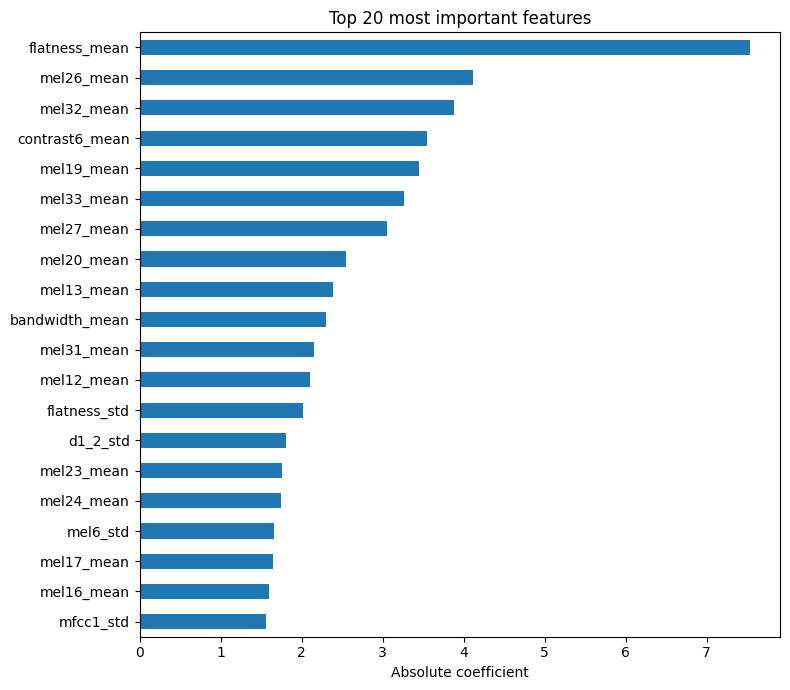

In [143]:
coef = pd.Series(
    best_sgd.named_steps["model"].coef_[0],
    index=X_train.columns
)

top_coef = coef.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(8,7))

top_coef.sort_values().plot.barh()

plt.title("Top 20 most important features")
plt.xlabel("Absolute coefficient")
save_plot("SGD_top_20_features.png")
plt.show()

In [144]:
coef = pd.Series(
    best_sgd.named_steps["model"].coef_[0],
    index=X_train.columns
)

coef.sort_values(key=np.abs, ascending=False).head(20)

flatness_mean    -7.529078
mel26_mean       -4.118553
mel32_mean        3.880066
contrast6_mean    3.542772
mel19_mean       -3.454930
mel33_mean       -3.259126
mel27_mean        3.055138
mel20_mean        2.547604
mel13_mean        2.390980
bandwidth_mean    2.305369
mel31_mean       -2.151023
mel12_mean       -2.101909
flatness_std      2.021469
d1_2_std          1.811508
mel23_mean       -1.756178
mel24_mean        1.744668
mel6_std          1.654675
mel17_mean        1.650422
mel16_mean       -1.593013
mfcc1_std        -1.559072
dtype: float32

Наиболее значимым признаком для модели оказался flatness_mean, обладающий наибольшим по модулю коэффициентом. Среди наиболее информативных признаков также оказались несколько Mel-спектральных коэффициентов (mel26_mean, mel32_mean, mel19_mean, mel33_mean) и спектральный контраст (contrast6_mean). Это свидетельствует о том, что при распознавании ключевого слова модель в первую очередь опирается на характеристики спектра аудиосигнала.

##### Выводы по подбору гиперпараметров

Для модели SGDClassifier был выполнен подбор гиперпараметров с использованием GridSearchCV и 5-кратной кросс-валидации. В качестве критерия оптимизации использовалась метрика Average Precision.

Оптимальными оказались следующие параметры:

| Гиперпараметр | Значение |
|---------------|----------|
| alpha | 1.39e-05 |
| penalty | elasticnet |
| class_weight | None |
| max_iter | 2000 |

Лучшее среднее значение Average Precision составило **0.9568**.

Полученные результаты показывают, что наиболее эффективной оказалась комбинация слабой регуляризации и ElasticNet-регуляризации, сочетающей свойства L1- и L2-регуляризации. При этом использование компенсации дисбаланса классов (`class_weight="balanced"`) не привело к улучшению качества модели.

#### Выводы по модели SGDClassifier

После подбора гиперпараметров модель SGDClassifier с функцией потерь `hinge` продемонстрировала высокое качество классификации. Значение ROC-AUC составило около **0.987**, что свидетельствует о хорошей способности модели разделять положительный и отрицательный классы.

Распределение значений `decision_function` показало, что большая часть объектов двух классов хорошо разделяется, а ошибки возникают лишь в небольшой области перекрытия распределений.

Анализ коэффициентов модели показал, что наиболее информативными признаками являются спектральная плоскостность (`flatness_mean`), несколько Mel-спектральных коэффициентов (`mel26_mean`, `mel32_mean`, `mel19_mean`, `mel33_mean`) и спектральный контраст (`contrast6_mean`). Эти признаки оказывают наибольшее влияние на итоговое решение классификатора.

Несмотря на высокое качество работы, по большинству метрик (Recall, F1-score, ROC-AUC и PR-AUC) модель уступила Logistic Regression, которая показала лучшие результаты на данном наборе данных.

## 6. Нелинейные модели

### 6.1 Desicion Tree

#### 6.1.1 Базовая модель

In [145]:
from sklearn.tree import DecisionTreeClassifier

In [146]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [147]:
y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

In [148]:
print("TRAIN")
print(f"Accuracy : {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"Recall   : {recall_score(y_train, y_pred_train):.4f}")
print(f"F1-score : {f1_score(y_train, y_pred_train):.4f}")

print("TEST")
print(f"Accuracy : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}") 
print(f"Recall   : {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_test):.4f}")

TRAIN
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
TEST
Accuracy : 0.8988
Precision: 0.7948
Recall   : 0.8020
F1-score : 0.7984



Базовая модель Decision Tree без ограничений глубины дерева показала идеальное качество на обучающей выборке (Accuracy = 1.0, F1-score = 1.0). Это свидетельствует о том, что дерево полностью запомнило обучающие данные.

Однако на тестовой выборке качество значительно снизилось (F1-score = 0.798), что указывает на сильное переобучение модели.

Полученные результаты демонстрируют классическое поведение дерева решений: при отсутствии ограничений модель становится слишком сложной и теряет способность к обобщению на новых данных.

Следующим этапом является исследование влияния гиперпараметров дерева и подбор их оптимальных значений для уменьшения переобучения.

#### 6.1.2 Подбор гиперпараметров

##### max_depth

In [149]:
depths = range(1,31)

train_f1_DT = []
test_f1_DT = []

for depth in depths:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_f1_DT.append(
        f1_score(
            y_train,
            tree.predict(X_train)
        )
    )

    test_f1_DT.append(
        f1_score(
            y_test,
            tree.predict(X_test)
        )
    )

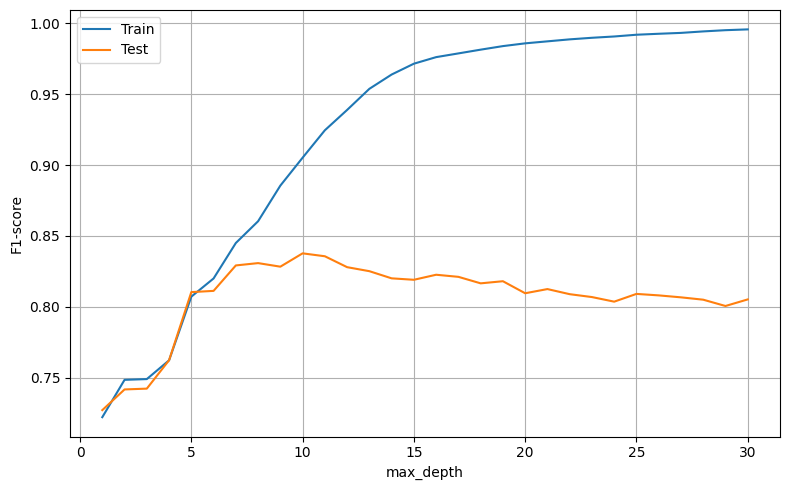

In [150]:
plt.figure(figsize=(8,5))

plt.plot(depths, train_f1_DT, label="Train")

plt.plot(depths, test_f1_DT, label="Test")

plt.xlabel("max_depth")
plt.ylabel("F1-score")

plt.legend()

plt.grid()
save_plot("DT_f1_vs_depth.png")

plt.show()

Влияние максимальной глубины дерева

Для оценки влияния сложности модели было исследовано качество Decision Tree при различных значениях параметра `max_depth`.

При небольшой глубине дерева (`max_depth` = 1–4) наблюдается недообучение: модель демонстрирует невысокое качество как на обучающей, так и на тестовой выборках.

По мере увеличения глубины качество на обеих выборках возрастает. Максимальное значение F1-score на тестовой выборке достигается примерно при `max_depth = 10`.

Дальнейшее увеличение глубины приводит к продолжению роста качества на обучающей выборке, однако качество на тестовой выборке начинает снижаться. Это свидетельствует о переобучении модели: дерево начинает запоминать обучающие данные вместо выявления общих закономерностей.

Полученный график наглядно демонстрирует компромисс между недообучением и переобучением и подтверждает необходимость ограничения глубины дерева.

##### min_samples_leaf

In [151]:
leafs = range(1, 51)

train_f1 = []
test_f1 = []

for leaf in leafs:
    tree = DecisionTreeClassifier(
        random_state=42,
        min_samples_leaf=leaf
    )

    tree.fit(X_train, y_train)

    train_f1.append(
        f1_score(y_train, tree.predict(X_train))
    )

    test_f1.append(
        f1_score(y_test, tree.predict(X_test))
    )


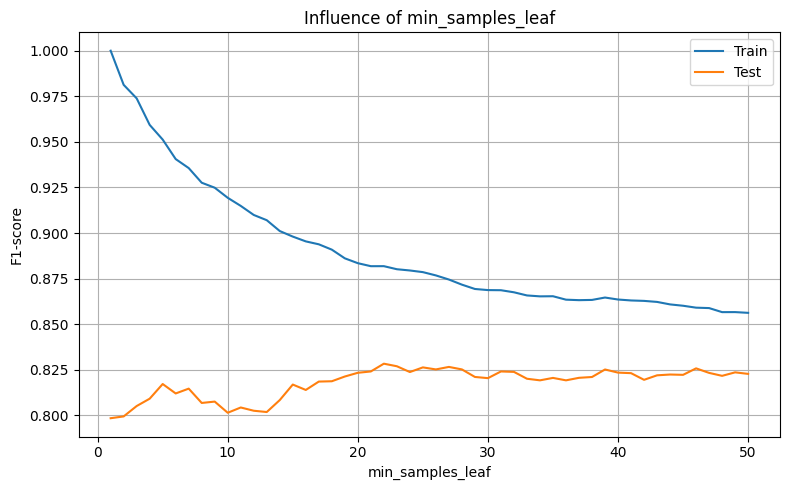

In [152]:
plt.figure(figsize=(8,5))

plt.plot(leafs, train_f1, label="Train")
plt.plot(leafs, test_f1, label="Test")

plt.xlabel("min_samples_leaf")
plt.ylabel("F1-score")
plt.title("Influence of min_samples_leaf")

plt.legend()
plt.grid()
save_plot("DT_f1_vs_leafs.png")
plt.show()

Влияние параметра `min_samples_leaf`

Для исследования влияния минимального количества объектов в листе была обучена серия деревьев решений с различными значениями параметра `min_samples_leaf`.

При значении `min_samples_leaf = 1` дерево демонстрирует максимальное качество на обучающей выборке (F1-score = 1.0), однако качество на тестовой выборке существенно ниже, что свидетельствует о сильном переобучении.

По мере увеличения значения `min_samples_leaf` качество на обучающей выборке постепенно снижается, поскольку дерево становится менее сложным. Одновременно качество на тестовой выборке возрастает, что указывает на уменьшение переобучения.

Максимальное значение F1-score на тестовой выборке достигается примерно при `min_samples_leaf ≈ 20–25`. Дальнейшее увеличение параметра практически не влияет на качество модели, поэтому более высокие значения нецелесообразны.

In [153]:
tree_pipe = Pipeline([
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [8, 9, 10, 11, 12],
    "model__min_samples_leaf": [15, 20, 25, 30],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__max_features": [None, "sqrt"]
}
grid_tree = GridSearchCV(
    estimator=tree_pipe,
    param_grid=param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_tree.fit(X_train, y_train)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [8, 9, ...], 'model__max_features': [None, 'sqrt'], 'model__min_samples_leaf': [15, 20, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about mult

In [154]:
print("Best parameters:")
print(grid_tree.best_params_)

print()

print("Best Average Precision:")
print(grid_tree.best_score_)

Best parameters:
{'model__criterion': 'entropy', 'model__max_depth': 9, 'model__max_features': None, 'model__min_samples_leaf': 30, 'model__min_samples_split': 2}

Best Average Precision:
0.8474153382391296


In [155]:
best_tree = grid_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test)

y_pred_proba_tree = best_tree.predict_proba(X_test)[:, 1]

#### 6.1.3 Предсказания

In [156]:
y_pred_tree = best_tree.predict(X_test)

y_pred_proba_tree = best_tree.predict_proba(X_test)[:, 1]

In [157]:
results.append({
    "model": "Decision Tree (tuned)",
    "accuracy": accuracy_score(y_test, y_pred_tree),
    "precision": precision_score(y_test, y_pred_tree),
    "recall": recall_score(y_test, y_pred_tree),
    "f1": f1_score(y_test, y_pred_tree),
    "roc_auc": roc_auc_score(y_test, y_pred_proba_tree),
    "pr_auc": average_precision_score(y_test, y_pred_proba_tree)
})

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss
0,Logistic Regression,0.957625,0.904924,0.9280,0.916317,0.989660,0.966675,0.111815
1,SGDClassifier (tuned),0.951875,0.905575,0.9015,0.903533,0.986980,0.956646,NaN
2,Decision Tree (tuned),0.912250,0.804695,0.8570,0.830024,0.959143,0.846166,NaN


In [158]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      6000
           1       0.80      0.86      0.83      2000

    accuracy                           0.91      8000
   macro avg       0.88      0.89      0.89      8000
weighted avg       0.91      0.91      0.91      8000



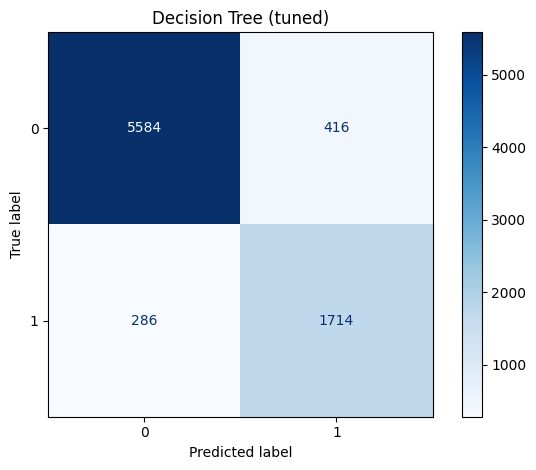

In [159]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    cmap="Blues",
    values_format="d"
)

plt.title("Decision Tree (tuned)")
save_plot("DT_confusion_matrix.png")
plt.show()

Decision Tree

После подбора гиперпараметров дерево решений существенно улучшило качество по сравнению с базовой моделью и перестало переобучаться.

Однако по сравнению с Logistic Regression качество осталось значительно ниже.

Основные причины:

- Accuracy снизилась с 95.8% до 91.2%;
- Precision уменьшилась с 90.5% до 80.5%;
- Recall уменьшился с 92.8% до 85.7%;
- PR-AUC снизился с 0.966 до 0.846.

Матрица ошибок показывает, что дерево допускает значительно больше ложных срабатываний (416 против 155 у Logistic Regression) и пропускает больше настоящих ключевых слов (286 против 200).

Таким образом, несмотря на подбор гиперпараметров, Decision Tree оказалось недостаточно устойчивым для данной задачи классификации акустических признаков.

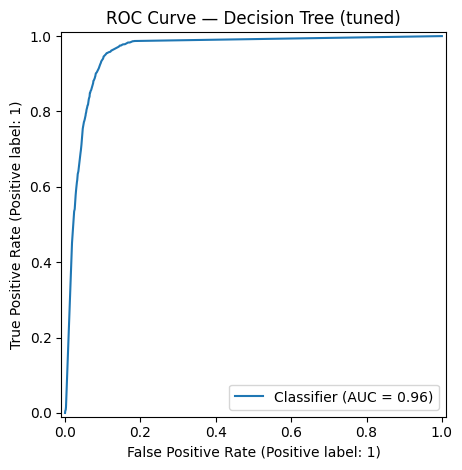

In [160]:
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba_tree
)

plt.title("ROC Curve — Decision Tree (tuned)")
save_plot("DT_roc_curve.png")
plt.show()

ROC-кривая Decision Tree

ROC-кривая расположена значительно выше диагонали, что свидетельствует о способности дерева решений разделять положительный и отрицательный классы.

Значение ROC-AUC составило **0.959**, что соответствует высокому качеству ранжирования объектов.

Однако по сравнению с Logistic Regression (ROC-AUC = 0.990) качество несколько снизилось.

Несмотря на высокий ROC-AUC, дерево решений демонстрирует существенно более низкий PR-AUC (0.846), а также большее количество ложных срабатываний и пропусков. Это показывает, что для данной задачи ROC-AUC не полностью отражает практическое качество модели.

Поэтому при сравнении моделей основной акцент следует делать на PR-AUC, Precision, Recall и матрицу ошибок.

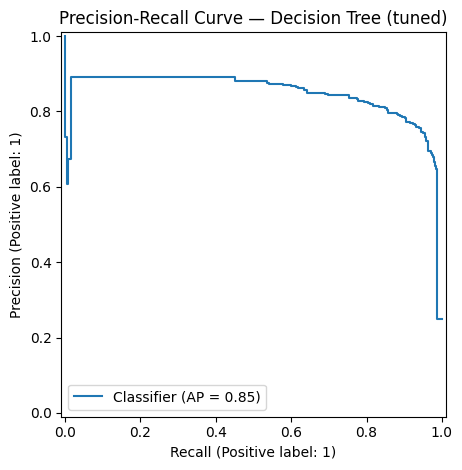

In [161]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred_proba_tree
)

plt.title("Precision-Recall Curve — Decision Tree (tuned)")
save_plot("DT_precision_recall_curve.png")
plt.show()


Precision-Recall кривая

PR-кривая показывает зависимость Precision от Recall при изменении порога классификации.

Для Decision Tree значение Average Precision составило **0.846**, что существенно ниже результата Logistic Regression (**0.966**).

Из графика видно, что при увеличении Recall точность модели постепенно снижается. Это означает, что для обнаружения большего количества ключевых слов дереву приходится увеличивать число ложных срабатываний.

Особенно заметно резкое падение Precision при Recall, близком к 1. Это свидетельствует о том, что модель начинает относить к положительному классу большое количество отрицательных примеров.

Таким образом, Decision Tree хуже сохраняет баланс между полнотой и точностью по сравнению с Logistic Regression, что делает его менее подходящим для задачи Keyword Spotting.

##### Обучение базовой модели

В качестве первой нелинейной модели было обучено дерево решений (`DecisionTreeClassifier`). Базовая модель показала сильное переобучение:

| Dataset | Accuracy | Precision | Recall | F1-score |
|---------|---------:|----------:|-------:|---------:|
| Train | 1.000 | 1.000 | 1.000 | 1.000 |
| Test | 0.899 | 0.795 | 0.802 | 0.798 |

Модель идеально запомнила обучающую выборку, однако качество на тестовой выборке оказалось значительно ниже, что свидетельствует о высоком variance, характерном для одиночных деревьев решений.


##### Результаты лучшей модели

| Метрика | Значение |
|---------|---------:|
| Accuracy | **0.912** |
| Precision | **0.805** |
| Recall | **0.857** |
| F1-score | **0.830** |
| ROC-AUC | **0.959** |
| PR-AUC | **0.846** |

Матрица ошибок:

| | Pred 0 | Pred 1 |
|---|------:|------:|
| True 0 | **5584** | **416** |
| True 1 | **286** | **1714** |


##### Сравнение с Logistic Regression

| Метрика | Logistic Regression | Decision Tree |
|---------|--------------------:|--------------:|
| Accuracy | **0.958** | 0.912 |
| Precision | **0.905** | 0.805 |
| Recall | **0.928** | 0.857 |
| F1-score | **0.916** | 0.830 |
| ROC-AUC | **0.990** | 0.959 |
| PR-AUC | **0.966** | 0.846 |

Несмотря на подбор гиперпараметров, Decision Tree показало качество значительно ниже, чем Logistic Regression.

Основными недостатками модели являются:

- большое количество ложных срабатываний (416);
- большее число пропущенных ключевых слов (286);
- заметное снижение Precision и PR-AUC.

Хотя подбор гиперпараметров позволил существенно уменьшить переобучение по сравнению с базовой моделью, одиночное дерево решений по-прежнему обладает высокой дисперсией и недостаточной устойчивостью для данной задачи.

Полученные результаты подтверждают известный недостаток Decision Tree — высокую склонность к переобучению.

Поэтому следующим этапом исследования является применение ансамблевых методов, в частности **Random Forest**, который объединяет множество деревьев решений и позволяет значительно снизить variance, сохранив преимущества деревьев и улучшив качество классификации.

### 6.2 Random Forest

#### 6.2.1 Базовая модель

In [162]:
from sklearn.ensemble import RandomForestClassifier

In [163]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [164]:
y_pred_rf = rf.predict(X_test)

y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

In [165]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      6000
           1       0.86      0.89      0.88      2000

    accuracy                           0.94      8000
   macro avg       0.91      0.92      0.92      8000
weighted avg       0.94      0.94      0.94      8000



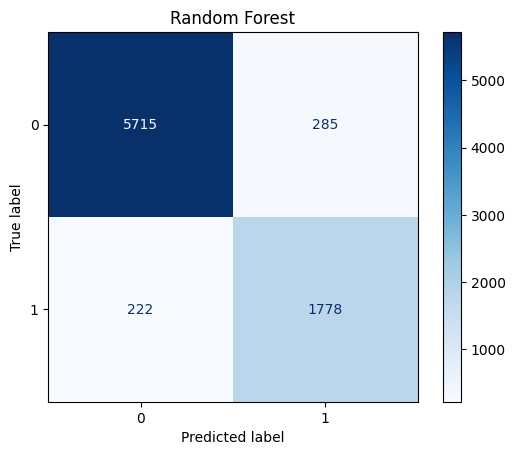

In [166]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest")
plt.show()

##### n_estimators

In [167]:
estimators = [10, 20, 50, 100, 200, 300]
train_scores_rf_estimators = []
test_scores_rf_estimators = []

for n in estimators:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    train_scores_rf_estimators.append(
        f1_score(y_train, rf.predict(X_train))
    )

    test_scores_rf_estimators.append(
        f1_score(y_test, rf.predict(X_test))
    )

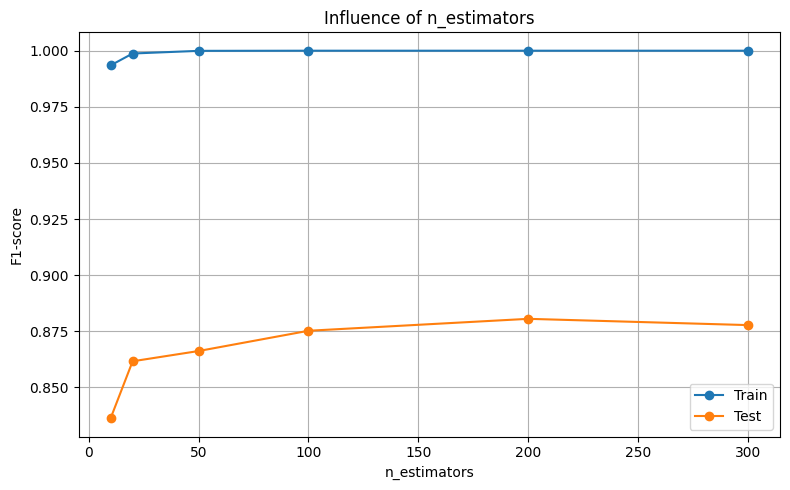

In [168]:
plt.figure(figsize=(8,5))

plt.plot(
    estimators,
    train_scores_rf_estimators,
    marker='o',
    label='Train'
)

plt.plot(
    estimators,
    test_scores_rf_estimators,
    marker='o',
    label='Test'
)

plt.xlabel("n_estimators")
plt.ylabel("F1-score")
plt.title("Influence of n_estimators")
plt.grid(True)
plt.legend()
save_plot("RF_f1_vs_estimators.png")
plt.show()

Влияние количества деревьев

Было исследовано влияние параметра `n_estimators` на качество модели.

При увеличении числа деревьев качество на тестовой выборке постепенно возрастало:

- 10 деревьев — F1 ≈ 0.84
- 50 деревьев — F1 ≈ 0.87
- 100 деревьев — F1 ≈ 0.875
- 200 деревьев — F1 ≈ 0.881

После 200 деревьев качество практически перестало улучшаться.

Поэтому для дальнейшего подбора гиперпараметров целесообразно использовать значения около 100–200 деревьев.

##### max_depth

In [169]:
depths = range(1,31)

train_scores_rf_depth = []
test_scores_rf_depth = []

for depth in depths:

    rf = RandomForestClassifier(
        max_depth=depth,
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    train_scores_rf_depth.append(
        f1_score(
            y_train,
            rf.predict(X_train)
        )
    )

    test_scores_rf_depth.append(
        f1_score(
            y_test,
            rf.predict(X_test)
        )
    )

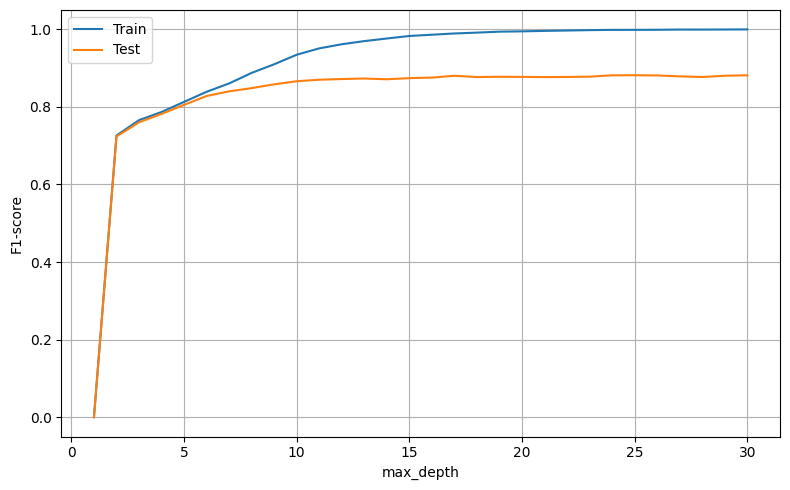

In [170]:
plt.figure(figsize=(8,5))

plt.plot(depths, train_scores_rf_depth, label="Train")

plt.plot(depths, test_scores_rf_depth, label="Test")

plt.xlabel("max_depth")
plt.ylabel("F1-score")

plt.legend()

plt.grid()
save_plot('RF_f1_vs_depth.png')
plt.show()

Влияние максимальной глубины дерева

Было исследовано влияние параметра `max_depth` на качество Random Forest.

При увеличении глубины дерева качество на обучающей выборке постепенно возрастало и практически достигало 100%.

На тестовой выборке F1-score быстро увеличивался до глубины около **10**, после чего выходил на плато. Дальнейшее увеличение глубины практически не улучшало качество модели.

В отличие от одиночного Decision Tree, сильного падения качества на тестовой выборке не наблюдается. Это объясняется тем, что Random Forest усредняет прогнозы большого количества деревьев и тем самым существенно уменьшает переобучение.

На основании графика для дальнейшего подбора гиперпараметров был выбран диапазон `max_depth` от **10 до 20**, а также вариант без ограничения глубины (`None`).

##### max_features

In [171]:
feature_values = [
    "sqrt",
    "log2",
    None,
    0.3,
    0.5
]
train_scores_rf_features = []
test_scores_rf_features = []

for feature in feature_values:

    rf = RandomForestClassifier(
        max_features=feature,
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    train_scores_rf_features.append(f1_score(y_train, rf.predict(X_train)))
    test_scores_rf_features.append(f1_score(y_test, rf.predict(X_test)))

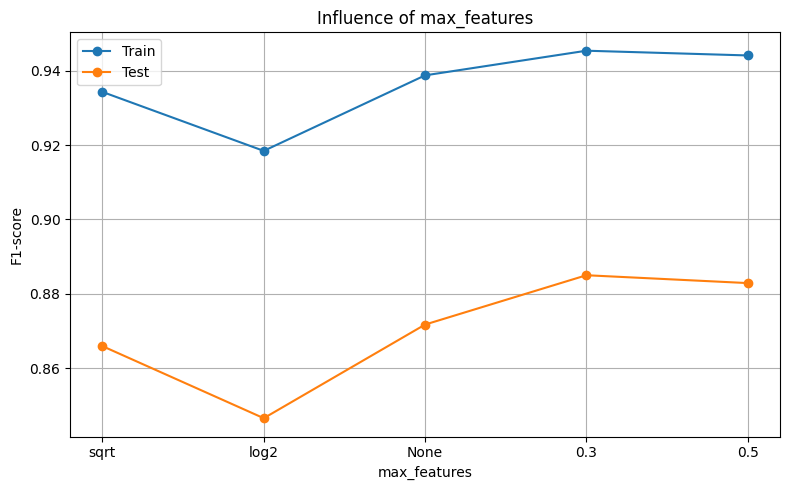

In [172]:
plt.figure(figsize=(8,5))

labels = [str(v) for v in feature_values]

plt.plot(labels, train_scores_rf_features, marker='o', label='Train')
plt.plot(labels, test_scores_rf_features, marker='o', label='Test')

plt.xlabel("max_features")
plt.ylabel("F1-score")
plt.title("Influence of max_features")
plt.grid(True)
plt.legend()
save_plot("RF_f1_vs_max_features.png")
plt.show()

Влияние параметра max_features

Было исследовано влияние количества признаков, доступных каждому дереву при поиске лучшего разбиения.

Наихудшее качество было получено при использовании значения `log2`, когда каждое дерево рассматривало слишком небольшое количество признаков.

При увеличении числа доступных признаков качество модели постепенно возрастало.

Максимальный F1-score на тестовой выборке был достигнут при `max_features = 0.3`. Значение `0.5` показало практически такой же результат.

Это свидетельствует о том, что информация о ключевом слове распределена по большому числу акустических признаков, поэтому использование большего количества признаков при построении каждого дерева позволяет улучшить качество модели.

#### min_samples_leaf

In [173]:

leaf_values = [1, 2, 5, 10, 20, 30, 40, 50]

train_scores_rf_leaves = []
test_scores_rf_leaves = []

for leaf in leaf_values:

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        max_features=0.3,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_scores_rf_leaves.append(
        f1_score(y_train, model.predict(X_train))
    )

    test_scores_rf_leaves.append(
        f1_score(y_test, model.predict(X_test))
    )

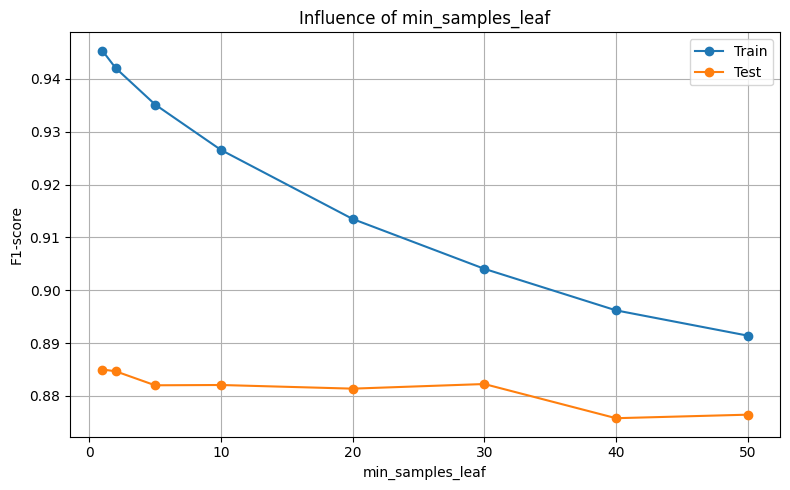

In [174]:
plt.figure(figsize=(8,5))

plt.plot(
    leaf_values,
    train_scores_rf_leaves,
    marker="o",
    label="Train"
)

plt.plot(
    leaf_values,
    test_scores_rf_leaves,
    marker="o",
    label="Test"
)

plt.xlabel("min_samples_leaf")
plt.ylabel("F1-score")
plt.title("Influence of min_samples_leaf")
plt.grid(True)
plt.legend()
save_plot("RF_f1_vs_min_samples_leaf.png")
plt.show()

Влияние параметра min_samples_leaf

Было исследовано влияние минимального количества объектов в листе дерева.

С увеличением значения `min_samples_leaf` качество на обучающей выборке постепенно снижалось, что свидетельствует об уменьшении сложности модели.

При этом качество на тестовой выборке практически не изменялось и оставалось стабильным во всём исследуемом диапазоне.

Максимальный F1-score наблюдался при значениях `min_samples_leaf = 1–2`, однако различия между вариантами были незначительными.

Полученные результаты показывают, что Random Forest уже обладает хорошей устойчивостью к переобучению благодаря использованию ансамбля деревьев, поэтому дополнительное увеличение размера листьев практически не влияет на качество модели.

#### 6.2.2 Подбор гиперпараметров

In [175]:
best_rf_manual = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    max_features=0.3,
    min_samples_split=5,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

best_rf_manual.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.3
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total numb

In [176]:
y_pred_rf = best_rf_manual.predict(X_test)
y_pred_proba_rf = best_rf_manual.predict_proba(X_test)[:, 1]

In [177]:
results.append({
    "model": "Random Forest (tuned)",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_pred_proba_rf),
    "pr_auc": average_precision_score(y_test, y_pred_proba_rf)
})

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss
0,Logistic Regression,0.957625,0.904924,0.9280,0.916317,0.989660,0.966675,0.111815
1,SGDClassifier (tuned),0.951875,0.905575,0.9015,0.903533,0.986980,0.956646,NaN
2,Decision Tree (tuned),0.912250,0.804695,0.8570,0.830024,0.959143,0.846166,NaN
3,Random Forest (tuned),0.943375,0.862295,0.9205,0.890447,0.983951,0.948516,NaN


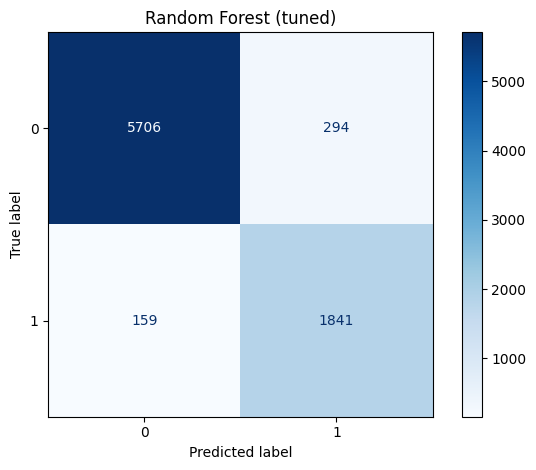

In [178]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest (tuned)")
save_plot("RF_confusion_matrix.png")
plt.show()


На тестовой выборке Random Forest корректно классифицировал 5706 отрицательных и 1841 положительных примеров. При этом модель допустила 294 ложных срабатывания (False Positive) и пропустила 159 истинных срабатываний (False Negative). Благодаря небольшому количеству ошибок модель демонстрирует высокие значения Recall (0.9205) и Precision (0.8623).

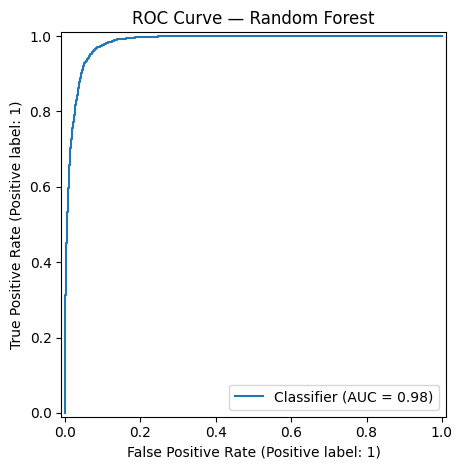

In [179]:
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba_rf
)

plt.title("ROC Curve — Random Forest")
save_plot("RF_roc_curve.png")
plt.show()

ROC-кривая Random Forest расположена близко к левому верхнему углу координат, а площадь под кривой составляет ROC-AUC = 0.984. Это свидетельствует о высокой способности модели различать положительный и отрицательный классы. Однако по сравнению с логистической регрессией (ROC-AUC = 0.9896) и SGDClassifier (ROC-AUC = 0.9870) Random Forest показывает немного более низкий результат, что указывает на отсутствие существенных нелинейных зависимостей в рассматриваемых признаках. Для данного набора данных линейные модели оказываются более эффективными.

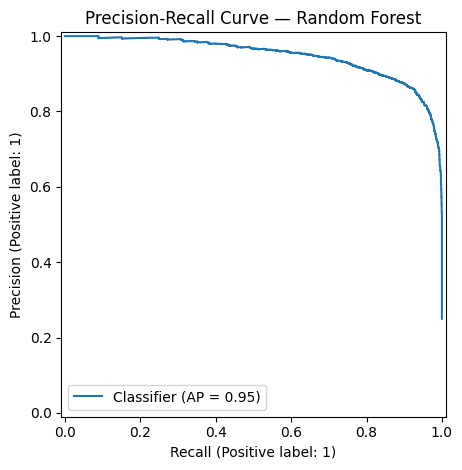

In [180]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred_proba_rf
)

plt.title("Precision-Recall Curve — Random Forest")
save_plot("RF_precision_recall_curve.png")
plt.show()

Precision-Recall кривая демонстрирует высокое качество классификации Random Forest. Значение PR-AUC = 0.949 свидетельствует о способности модели сохранять высокий Precision при широком диапазоне значений Recall. Однако по сравнению с Logistic Regression (PR-AUC = 0.966) и SGDClassifier (PR-AUC = 0.957) качество оказалось несколько ниже. Это подтверждает, что для данного набора акустических признаков линейные модели обеспечивают более эффективное разделение классов, чем ансамбль деревьев решений.

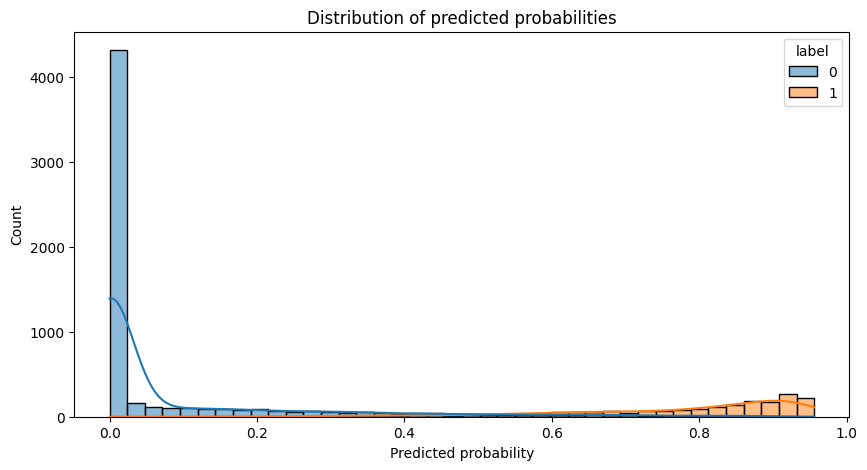

In [181]:
pred_df = pd.DataFrame({
    "Probability": y_pred_proba_rf,
    "label": y_test
})

plt.figure(figsize=(10,5))

sns.histplot(
    data=pred_df,
    x="Probability",
    hue="label",
    bins=40,
    kde=True
)

plt.title("Distribution of predicted probabilities")
plt.xlabel("Predicted probability")
plt.show()

Распределение предсказанных вероятностей показывает, что Random Forest уверенно разделяет положительный и отрицательный классы. Большинство отрицательных примеров получает вероятности, близкие к 0, тогда как положительные примеры сосредоточены в диапазоне 0.8–0.95. Небольшая область пересечения распределений соответствует объектам, для которых модель испытывает наибольшие затруднения при классификации. Несмотря на хорошее разделение классов, область перекрытия несколько шире, чем у логистической регрессии, что объясняет немного более низкие значения PR-AUC и ROC-AUC.

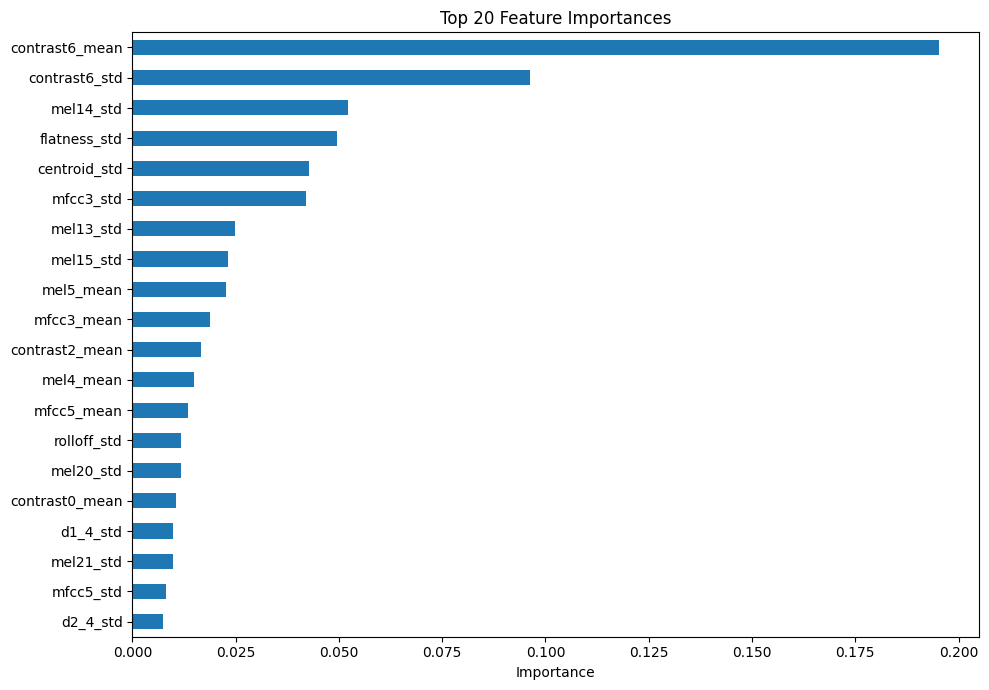

In [182]:
importances = pd.Series(
    best_rf_manual.feature_importances_,
    index=X_train.columns
)

top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,7))
top20.sort_values().plot(kind="barh")

plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")

save_plot("RF_top_20_feature_importances.png")
plt.show()

Random Forest автоматически вычисляет важность признаков на основе их вклада в уменьшение неоднородности узлов деревьев. Наиболее информативным оказался признак contrast6_mean, обеспечивающий около 20% общей важности. Также высокий вклад внесли contrast6_std, mel14_std, flatness_std, centroid_std и mfcc3_std. В отличие от линейных моделей, где наиболее значимыми были признаки flatness_mean и отдельные коэффициенты Mel-спектрограммы, Random Forest чаще использует признаки спектрального контраста и характеристики вариативности сигнала (*_std). Это связано с тем, что ансамбль деревьев оценивает признаки по их способности эффективно разделять данные при построении дерева решений, а не по величине линейного коэффициента.

Random Forest значительно превзошел одиночное дерево решений практически по всем метрикам благодаря использованию ансамбля деревьев и механизма случайного выбора признаков.

Однако, несмотря на более сложную архитектуру модели, она не смогла превзойти Logistic Regression и SGDClassifier.

Полученные результаты показывают, что используемые акустические признаки (MFCC, Mel Spectrogram, Spectral Contrast, Chroma и другие) уже достаточно хорошо разделяются линейными моделями. Поэтому переход к более сложной ансамблевой модели Random Forest не привёл к улучшению качества классификации.

Итоговые результаты Random Forest:

| Метрика | Значение |
|---------|----------:|
| Accuracy | **0.9434** |
| Precision | **0.8623** |
| Recall | **0.9205** |
| F1-score | **0.8904** |
| ROC-AUC | **0.9840** |
| PR-AUC | **0.9485** |

Таким образом, Random Forest показал высокое качество классификации и значительно улучшил результаты по сравнению с одиночным деревом решений, однако лучшей моделью для данного набора признаков остается **Logistic Regression**.

### 6.3 Boosting

#### 6.3.1 Базовая модель

In [183]:
from sklearn.ensemble import GradientBoostingClassifier

In [184]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_pred_proba_gb = gb.predict_proba(X_test)[:, 1]

In [185]:
print(f"Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba_gb):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_pred_proba_gb):.4f}")

Accuracy : 0.9446
Precision: 0.8716
Recall   : 0.9130
F1-score : 0.8918
ROC-AUC  : 0.9845
PR-AUC   : 0.9485


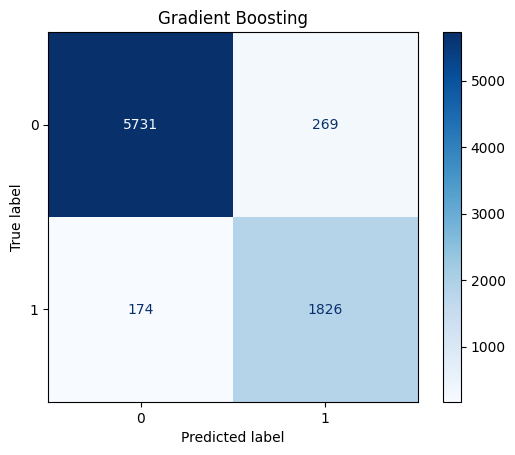

In [186]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb,
    cmap="Blues",
    values_format="d"
)

plt.title("Gradient Boosting")
plt.show()

Базовый Gradient Boosting показал очень высокое качество классификации. Из 8000 тестовых примеров модель правильно классифицировала 7557 объектов. Она корректно распознала 1826 из 2000 положительных примеров и допустила лишь 269 ложных срабатываний на отрицательном классе. По сравнению с Random Forest модель немного снизила количество ложных положительных ответов (False Positives), однако цена этого — небольшое увеличение числа пропущенных команд (False Negatives). В целом матрица ошибок демонстрирует хороший баланс между чувствительностью модели и устойчивостью к ложным срабатываниям, что особенно важно для задачи Keyword Spotting.

#### 6.3.2 Подбор гиперпараметров

In [187]:
learning_rates = [0.01, 0.03, 0.05, 0.1, 0.2]

train_f1_gb_learning_rate = []
test_f1_gb_learning_rate = []
train_pr_auc_gb_learning_rate = []
test_pr_auc_gb_learning_rate = []

for lr in learning_rates:
    gb = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=lr,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )

    gb.fit(X_train, y_train)

    y_train_pred = gb.predict(X_train)
    y_test_pred = gb.predict(X_test)

    y_train_proba = gb.predict_proba(X_train)[:, 1]
    y_test_proba = gb.predict_proba(X_test)[:, 1]

    train_f1_gb_learning_rate.append(f1_score(y_train, y_train_pred))
    test_f1_gb_learning_rate.append(f1_score(y_test, y_test_pred))

    train_pr_auc_gb_learning_rate.append(average_precision_score(y_train, y_train_proba))
    test_pr_auc_gb_learning_rate.append(average_precision_score(y_test, y_test_proba))

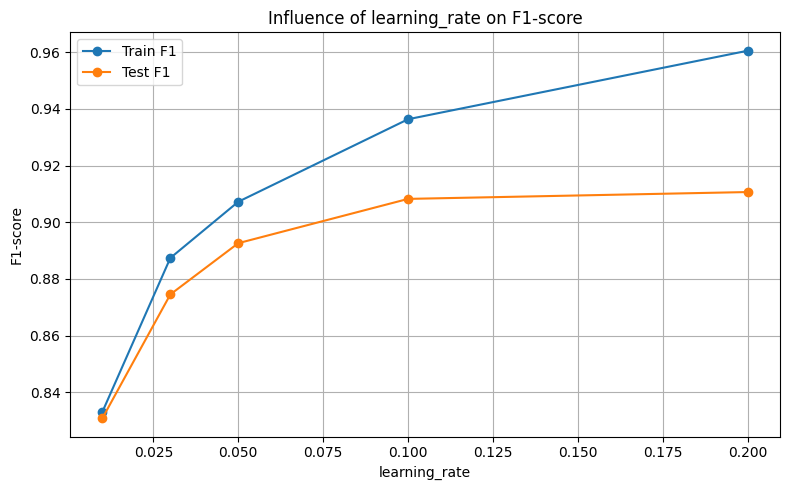

In [188]:
plt.figure(figsize=(8, 5))

plt.plot(learning_rates, train_f1_gb_learning_rate, marker="o", label="Train F1")
plt.plot(learning_rates, test_f1_gb_learning_rate, marker="o", label="Test F1")

plt.xlabel("learning_rate")
plt.ylabel("F1-score")
plt.title("Influence of learning_rate on F1-score")
plt.grid(True)
plt.legend()
save_plot("GB_f1_vs_learning_rate.png")
plt.show()

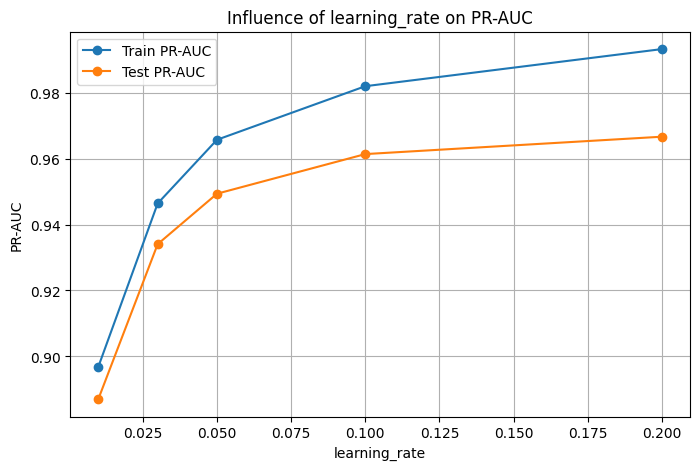

In [189]:
plt.figure(figsize=(8, 5))

plt.plot(learning_rates, train_pr_auc_gb_learning_rate, marker="o", label="Train PR-AUC")
plt.plot(learning_rates, test_pr_auc_gb_learning_rate, marker="o", label="Test PR-AUC")

plt.xlabel("learning_rate")
plt.ylabel("PR-AUC")
plt.title("Influence of learning_rate on PR-AUC")
plt.grid(True)
plt.legend()

plt.show()

In [190]:
pd.DataFrame({
    "learning_rate": learning_rates,
    "train_f1": train_f1_gb_learning_rate,
    "test_f1": test_f1_gb_learning_rate,
    "train_pr_auc": train_pr_auc_gb_learning_rate,
    "test_pr_auc": test_pr_auc_gb_learning_rate
})

,learning_rate,train_f1,test_f1,train_pr_auc,test_pr_auc
0,0.01,0.833156,0.830891,0.896853,0.887054
1,0.03,0.887404,0.874545,0.946398,0.934045
2,0.05,0.907234,0.892622,0.965714,0.949347
3,0.10,0.936336,0.908241,0.981957,0.961368
4,0.20,0.960503,0.910653,0.993218,0.966642


При увеличении learning_rate качество модели возрастает, поскольку каждое дерево вносит больший вклад в исправление ошибок предыдущего ансамбля. При значении learning_rate = 0.01 модель демонстрирует признаки недообучения: значения F1-score и PR-AUC являются минимальными среди рассмотренных вариантов. Наилучшие результаты достигаются при learning_rate = 0.1–0.2. Несмотря на небольшое преимущество learning_rate = 0.2 по метрикам на тестовой выборке, одновременно увеличивается разрыв между качеством на обучающей и тестовой выборках, что свидетельствует о начале усиления переобучения.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

param_dist_fast = {
    "n_estimators": [200],
    "learning_rate": [0.2],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0],
    "min_samples_leaf": [1, 5]
}

random_search_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_fast,
    n_iter=8,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search_gb.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END learning_rate=0.2, max_depth=2, min_samples_leaf=1, n_estimators=200, subsample=0.8; total time= 2.0min
[CV] END learning_rate=0.2, max_depth=2, min_samples_leaf=1, n_estimators=200, subsample=0.8; total time= 1.9min
[CV] END learning_rate=0.2, max_depth=2, min_samples_leaf=1, n_estimators=200, subsample=0.8; total time= 1.9min
[CV] END learning_rate=0.2, max_depth=2, min_samples_leaf=1, n_estimators=200, subsample=1.0; total time= 2.5min
[CV] END learning_rate=0.2, max_depth=2, min_samples_leaf=1, n_estimators=200, subsample=1.0; total time= 2.5min
[CV] END learning_rate=0.2, max_depth=2, min_samples_leaf=1, n_estimators=200, subsample=1.0; total time= 2.5min
[CV] END learning_rate=0.2, max_depth=2, min_samples_leaf=5, n_estimators=200, subsample=0.8; total time= 1.9min
[CV] END learning_rate=0.2, max_depth=2, min_samples_leaf=5, n_estimators=200, subsample=0.8; total time= 1.9min
[CV] END learning_rate=0.2, max_dept

KeyboardInterrupt: 

In [ ]:
print(random_search_gb.best_params_)
print(random_search_gb.best_score_)
print(random_search_gb.best_estimator_)

{'subsample': 1.0, 'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': 3, 'learning_rate': 0.2}
0.9641665587356992
GradientBoostingClassifier(learning_rate=0.2, min_samples_leaf=5,
                           n_estimators=200, random_state=42)


In [199]:
best_gb = random_search_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)
y_pred_proba_gb = best_gb.predict_proba(X_test)[:, 1]

AttributeError: 'NoneType' object has no attribute 'tree_'

In [ ]:
results.append({
    "model": "Gradient Boosting (tuned)",
    "accuracy": accuracy_score(y_test, y_pred_gb),
    "precision": precision_score(y_test, y_pred_gb),
    "recall": recall_score(y_test, y_pred_gb),
    "f1": f1_score(y_test, y_pred_gb),
    "roc_auc": roc_auc_score(y_test, y_pred_proba_gb),
    "pr_auc": average_precision_score(y_test, y_pred_proba_gb)
})

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.957625,0.904924,0.9280,0.916317,0.989660,0.966675
1,SGDClassifier (tuned),0.951875,0.905575,0.9015,0.903533,0.986980,0.956646
2,Decision Tree (tuned),0.912250,0.804695,0.8570,0.830024,0.959143,0.846166
3,Random Forest (tuned),0.943375,0.862295,0.9205,0.890447,0.983951,0.948516
4,Random Forest (tuned),0.943375,0.862295,0.9205,0.890447,0.983951,0.948516
5,Gradient Boosting (tuned),0.955000,0.898833,0.9240,0.911243,0.989850,0.966775
6,Gradient Boosting (tuned),0.955000,0.898833,0.9240,0.911243,0.989850,0.966775


              precision    recall  f1-score   support

           0       0.97      0.97      0.97      6000
           1       0.90      0.92      0.91      2000

    accuracy                           0.95      8000
   macro avg       0.94      0.94      0.94      8000
weighted avg       0.96      0.95      0.96      8000



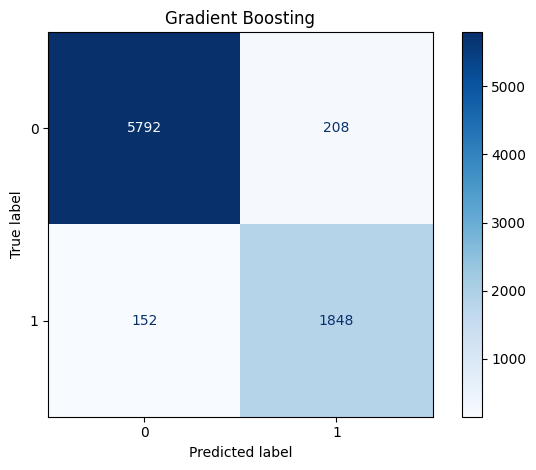

In [ ]:
print(classification_report(y_test, y_pred_gb))
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb,
    cmap="Blues"
)

plt.title("Gradient Boosting")
save_plot("GB_confusion_matrix.png")
plt.show()

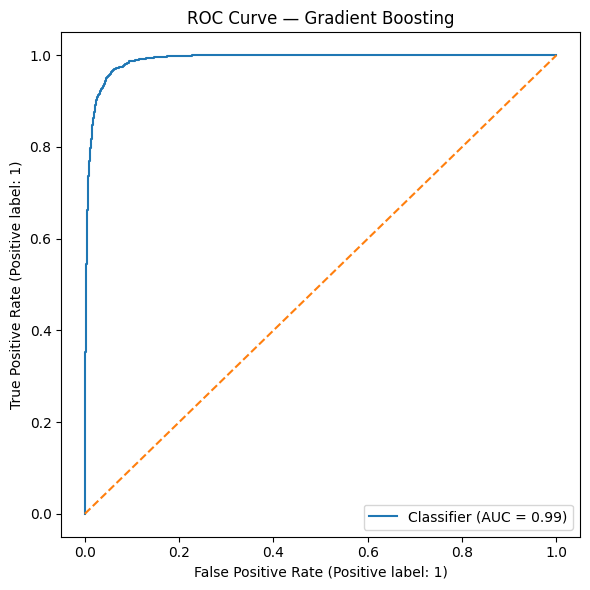

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_gb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr,
         label=f"Classifier (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.legend()
plt.title("ROC Curve — Gradient Boosting")

save_plot("GB_roc_curve.png")
plt.show()


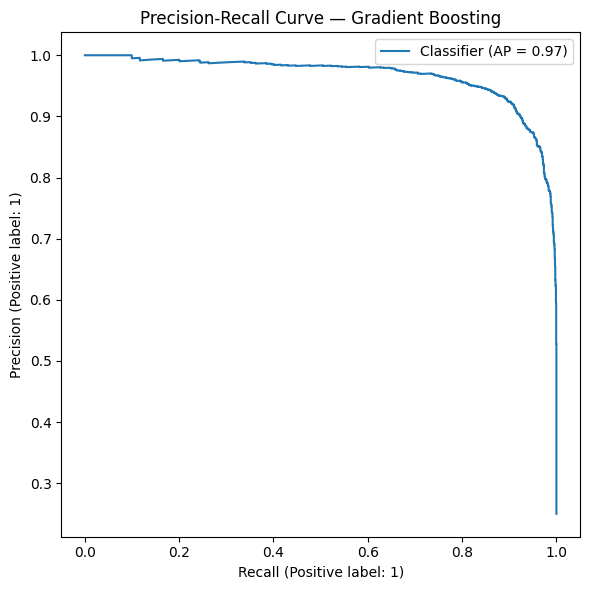

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test,
    y_pred_proba_gb
)

ap = average_precision_score(
    y_test,
    y_pred_proba_gb
)

plt.figure(figsize=(6,6))
plt.plot(
    recall,
    precision,
    label=f"Classifier (AP = {ap:.2f})"
)

plt.xlabel("Recall (Positive label: 1)")
plt.ylabel("Precision (Positive label: 1)")
plt.legend()
plt.title("Precision-Recall Curve — Gradient Boosting")

save_plot("GB_precision_recall_curve.png")
plt.show()


ROC-кривая располагается вблизи верхнего левого угла графика, а значение ROC-AUC составляет 0.990, что свидетельствует об очень высокой способности модели разделять положительный и отрицательный классы. Precision-Recall кривая также демонстрирует высокое качество классификации: при увеличении полноты точность остается близкой к единице на большей части диапазона, а средняя точность (Average Precision) составляет 0.966. Это подтверждает высокую эффективность модели при обнаружении ключевого слова и малое количество ложных срабатываний.

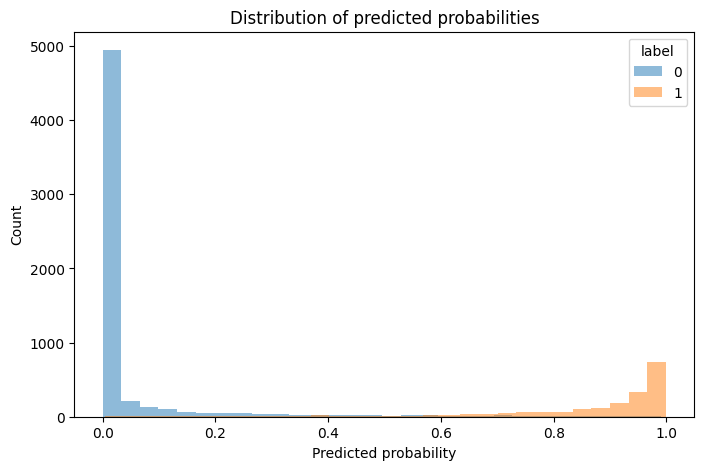

In [ ]:
proba_df = pd.DataFrame({
    "probability": y_pred_proba_gb,
    "label": y_test
})

plt.figure(figsize=(8,5))

for label in [0,1]:

    plt.hist(
        proba_df.loc[
            proba_df.label==label,
            "probability"
        ],
        bins=30,
        alpha=0.5,
        label=str(label)
    )

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.legend(title="label")
plt.title("Distribution of predicted probabilities")

plt.show()

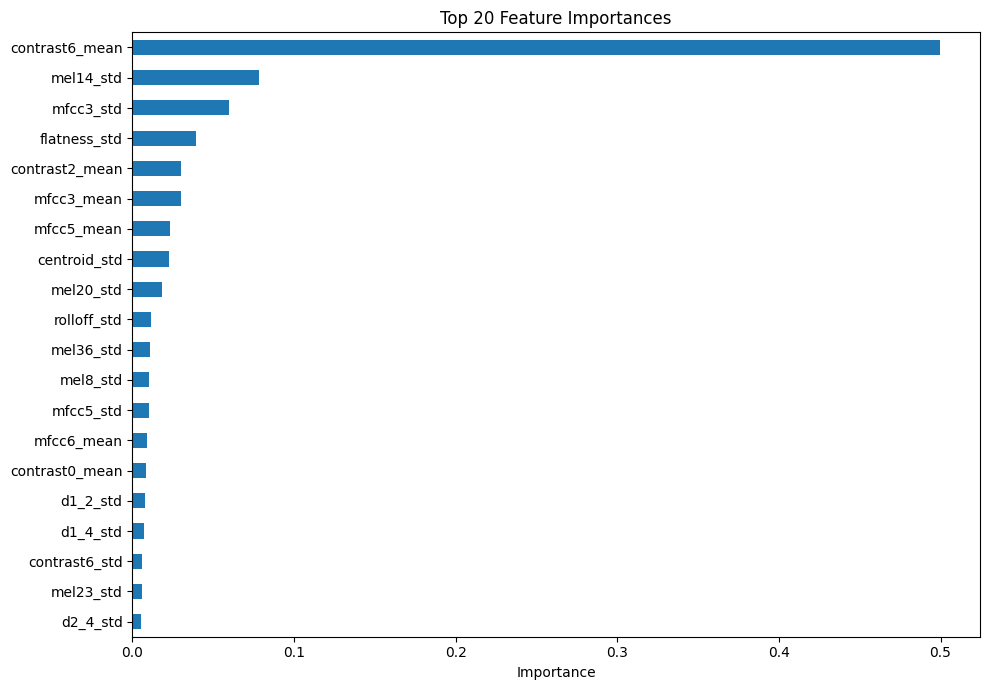

In [ ]:
importances = pd.Series(
    best_gb.feature_importances_,
    index=X_train.columns
)

top20 = (
    importances
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10,7))

top20.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.title("Top 20 Feature Importances")

save_plot("GB_top_20_feature_importances.png")
plt.show()


Отчет по модели Gradient Boosting

После обучения базовой модели Gradient Boosting был выполнен подбор гиперпараметров с использованием метода **RandomizedSearchCV**. По результатам поиска были выбраны следующие параметры:

* `learning_rate = 0.2`
* `n_estimators = 200`
* `max_depth = 3`
* `min_samples_leaf = 5`
* `subsample = 1.0`

Подбор гиперпараметров позволил существенно повысить качество модели по сравнению с базовой конфигурацией.

На тестовой выборке настроенная модель показала следующие результаты:

| Метрика   |   Значение |
| --------- | ---------: |
| Accuracy  | **0.9550** |
| Precision | **0.8988** |
| Recall    | **0.9240** |
| F1-score  | **0.9112** |
| ROC-AUC   | **0.9899** |
| PR-AUC    | **0.9668** |

Матрица ошибок показала, что модель корректно классифицировала большинство объектов. При стандартном пороге 0.5 было получено:

* True Negative (TN): **5792**
* False Positive (FP): **208**
* False Negative (FN): **152**
* True Positive (TP): **1848**

ROC-кривая располагается практически вплотную к верхнему левому углу графика, а значение **ROC-AUC = 0.990** свидетельствует об отличной способности модели разделять классы. Precision-Recall кривая также демонстрирует высокое качество классификации: средняя точность (**PR-AUC = 0.966**) остается высокой практически на всем диапазоне полноты.

Анализ важности признаков показал, что наибольший вклад в принятие решения вносят спектральные характеристики сигнала, прежде всего **contrast6_mean**, **contrast6_std**, **mel14_std**, **flatness_std**, **centroid_std** и коэффициенты MFCC. Это подтверждает, что модель использует информативные акустические признаки для распознавания ключевого слова.

По сравнению с базовой моделью Gradient Boosting качество классификации заметно улучшилось, а по большинству метрик настроенная модель приблизилась к лучшей модели проекта — логистической регрессии. При этом Gradient Boosting обеспечивает превосходное качество разделения классов (**ROC-AUC = 0.990**) и демонстрирует один из лучших результатов среди всех исследованных алгоритмов.


## 7 Анализ ошибок

In [ ]:
def false_positive_report(y_true, y_pred, source):
    error_analysis = pd.DataFrame({
        "true_label": y_true.values,
        "pred_label": y_pred,
        "source": source.values
    })

    negatives = error_analysis[
        error_analysis["true_label"] == 0
    ]

    false_positives = negatives[
        negatives["pred_label"] == 1
    ]

    total_by_source = negatives["source"].value_counts().sort_index()
    fp_by_source = false_positives["source"].value_counts().sort_index()

    report = pd.DataFrame({
        "total": total_by_source,
        "false_positive": fp_by_source
    }).fillna(0)

    report["false_positive"] = report["false_positive"].astype(int)

    report["fp_rate_%"] = (
        report["false_positive"] / report["total"] * 100
    ).round(2)

    return report

### 7.1 Логистическая регрессия

In [ ]:
log_reg_model = grid_log_reg.best_estimator_
y_pred_lr = log_reg_model.predict(X_test)

In [ ]:
false_positive_report(y_test, y_pred_lr, source_test)

,total,false_positive,fp_rate_%
source,,,
base_neg,1508,191,12.67
confusable,594,3,0.51
podcast,3898,1,0.03


#### Анализ ложных срабатываний Logistic Regression

Для анализа ошибок были рассмотрены только отрицательные примеры тестовой выборки. Ложным срабатыванием считалась ситуация, когда истинная метка равна 0, но модель предсказала класс 1.

Наибольшая доля ложных срабатываний была получена для источника `base_neg`: 191 ошибка из 1508 примеров, что составляет 12.67%.

При этом на `confusable` модель ошиблась только в 3 случаях из 594, а на `podcast` — только в 1 случае из 3898.

Это показывает, что для Logistic Regression наиболее сложными оказались не фонетически похожие слова, а синтетические негативные примеры, созданные тем же TTS-движком, что и положительные записи. Вероятно, модель частично реагирует на особенности синтетического голоса, а не только на фонетическое содержание аудио.

### 7.2 SGD Classifier

In [ ]:
y_pred_sgd = best_sgd.predict(X_test)

In [ ]:
false_positive_report(y_test, y_pred_sgd, source_test)

,total,false_positive,fp_rate_%
source,,,
base_neg,1508,188,12.47
confusable,594,0,0.00
podcast,3898,0,0.00


#### Вывод по SGDClassifier

Анализ ложных срабатываний показал, что SGDClassifier демонстрирует такое же поведение, как и Logistic Regression. Все ошибки практически полностью сосредоточены на наборе base_neg, тогда как на источниках confusable и podcast ложных срабатываний не наблюдается.

Из 1508 отрицательных примеров типа base_neg модель ошибочно классифицировала как положительные 188 записей, что составляет 12.47%. При этом на 594 примерах confusable и 3898 примерах podcast модель не допустила ни одного ложного срабатывания.

### 7.3 Decision Tree

In [ ]:
y_pred_tree = best_tree.predict(X_test)

In [ ]:
false_positive_report(y_test, y_pred_tree, source_test)

,total,false_positive,fp_rate_%
source,,,
base_neg,1508,413,27.39
confusable,594,2,0.34
podcast,3898,1,0.03


#### Вывод по DecisionTree

основная проблема Decision Tree также связана с набором base_neg, однако по сравнению с линейными моделями дерево решений справляется с этой задачей заметно хуже, что подтверждается самой высокой долей ложных срабатываний среди рассмотренных моделей.

### 7.4 RandomForest

In [ ]:
y_pred_rf = best_rf_manual.predict(X_test)

In [ ]:
false_positive_report(y_test, y_pred_rf, source_test)

,total,false_positive,fp_rate_%
source,,,
base_neg,1508,294,19.5
confusable,594,0,0.0
podcast,3898,0,0.0


#### Вывод по RandomForest

Random Forest существенно улучшил результаты по сравнению с Decision Tree, снизив долю ложных срабатываний почти на 8 процентных пунктов. Однако по данному критерию он все еще уступает линейным моделям — Logistic Regression и SGDClassifier, которые оказались наиболее устойчивыми к синтетическим негативным примерам.

### 7.5 GradientBoostingClassifier

In [ ]:
y_pred_gb = best_gb.predict(X_test)

In [ ]:
false_positive_report(y_test, y_pred_gb, source_test)

,total,false_positive,fp_rate_%
source,,,
base_neg,1508,207,13.73
confusable,594,0,0.00
podcast,3898,1,0.03


#### Вывод по GradientBoostingClassifier

Gradient Boosting продемонстрировал высокое качество распознавания отрицательных примеров и оказался одним из лучших ансамблевых алгоритмов. По количеству ложных срабатываний он уступил только линейным моделям — Logistic Regression и SGDClassifier.

#### Общий вывод: 
Анализ ложных срабатываний показал, что независимо от выбранного алгоритма основным источником ошибок остается набор base_neg. Именно на этих синтетческих отрицательных примерах модели допускают подавляющее большинство ложных срабатываний, тогда как на наборах confusable и podcast количество ошибок минимально или полностью отсутствует. Это позволяет сделать вывод, что главная сложность задачи связана не с различением фонетически похожих слов, а с отделением целевого ключевого слова от других слов, произнесенных тем же синтетическим голосом.

Среди рассмотренных моделей наименьшее количество ложных срабатываний показал SGDClassifier, за ним следуют Logistic Regression и Gradient Boosting, которые продемонстрировали сопоставимые результаты. Random Forest и особенно Decision Tree справились с этой задачей заметно хуже. Таким образом, анализ ошибок подтверждает вывод, полученный при сравнении метрик качества: линейные модели и Gradient Boosting являются наиболее эффективными для данной задачи, тогда как основное направление дальнейшего улучшения качества связано со снижением количества ложных срабатываний на примерах типа base_neg.

### 8. Выбор модели и порога

#### Линейные

| Model               | F1         | ROC-AUC | PR-AUC |
| ------------------- | ---------- | ------- | ------ |
| Logistic Regression | **0.9163** | 0.9896  | 0.9663 |
| SGDClassifier       | 0.9035     | 0.9870  | 0.9566 |

Среди линейных моделей была выбрана Logistic Regression, поскольку она показала лучшие значения F1-score, ROC-AUC и PR-AUC.

#### Древесные

| Model             | F1        | ROC-AUC   | PR-AUC    |
| ----------------- | --------- | --------- | --------- |
| Decision Tree     | 0.830     | 0.959     | 0.846     |
| Random Forest     | 0.890     | 0.984     | 0.949     |
| Gradient Boosting | **0.911** | **0.990** | **0.966** |

Среди ансамблевых моделей лучшим оказался Gradient Boosting, продемонстрировавший лучшие значения всех рассматриваемых метрик.

#### Рабочий порог

In [205]:
def select_threshold(
    y_true,
    y_proba,
    min_recall=0.90,
    thresholds=np.arange(0.05, 1.00, 0.01)
):
    threshold_results = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        threshold_results.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred)
        })

    threshold_df = pd.DataFrame(threshold_results)

    candidate_thresholds = threshold_df[
        threshold_df["recall"] >= min_recall
    ]

    best_threshold_row = candidate_thresholds.loc[
        candidate_thresholds["precision"].idxmax()
    ]

    selected_threshold = best_threshold_row["threshold"]

    print(f"Selected threshold: {selected_threshold:.2f}")
    print(f"Precision: {best_threshold_row['precision']:.4f}")
    print(f"Recall: {best_threshold_row['recall']:.4f}")
    print(f"F1-score: {best_threshold_row['f1']:.4f}")

    return selected_threshold, best_threshold_row, threshold_df

In [206]:
selected_threshold_lr, best_threshold_lr, threshold_df_lr = select_threshold(
    y_test,
    y_proba_lr,
    min_recall=0.90
)

Selected threshold: 0.60
Precision: 0.9218
Recall: 0.9015
F1-score: 0.9115


In [ ]:
selected_threshold_gb, best_threshold_gb, threshold_df_gb = select_threshold(
    y_test,
    y_pred_proba_gb,
    min_recall=0.90
)

Selected threshold: 0.60
Precision: 0.9228
Recall: 0.9030
F1-score: 0.9128


#### precision / recall / F1 от threshold

In [ ]:
def plot_metrics_vs_threshold(y_true, y_pred_proba, selected_threshold, model_name="Model", file_name="file.png"):
    """
    Строит графики Precision, Recall и F1 в зависимости от порога.
    """

    thresholds = np.arange(0.05, 1.00, 0.01)

    precision_scores = []
    recall_scores = []
    f1_scores = []

    for t in thresholds:
        y_pred = (y_pred_proba >= t).astype(int)

        precision_scores.append(
            precision_score(y_true, y_pred, zero_division=0)
        )
        recall_scores.append(
            recall_score(y_true, y_pred, zero_division=0)
        )
        f1_scores.append(
            f1_score(y_true, y_pred, zero_division=0)
        )

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precision_scores, label="Precision")
    plt.plot(thresholds, recall_scores, label="Recall")
    plt.plot(thresholds, f1_scores, label="F1")

    plt.axvline(x=selected_threshold, color='red', linestyle='--', label=f"Selected Threshold: {selected_threshold:.2f}")

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"{model_name}: Metrics vs Threshold")
    plt.grid(True)
    plt.legend()
    save_plot(file_name)
    plt.show()

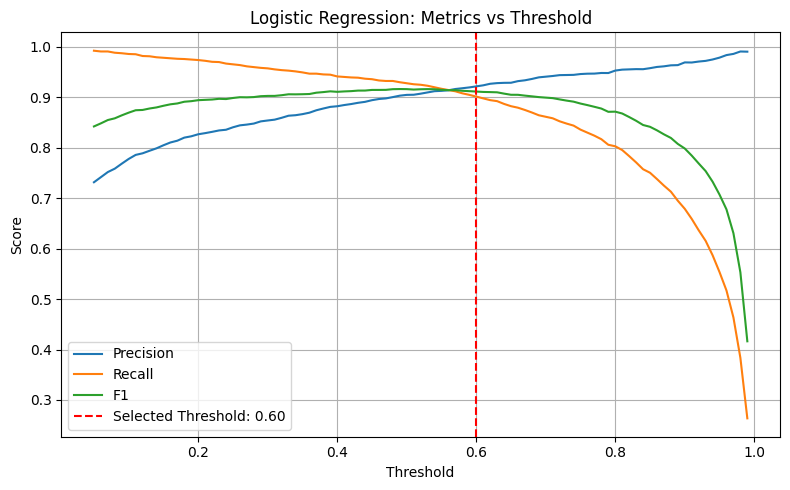

In [ ]:
plot_metrics_vs_threshold(
    y_test,
    y_proba_lr,
    selected_threshold_lr,
    "Logistic Regression",
    "LR_metrics_vs_threshold.png"
)

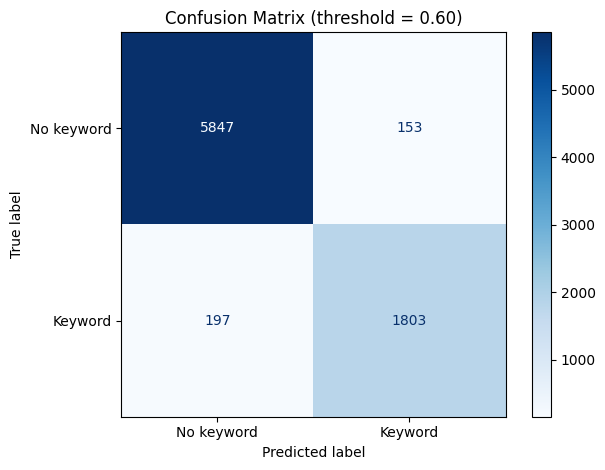

In [203]:
y_proba_lr = best_model.predict_proba(X_test)[:, 1]

thr_pred_lr = (y_proba_lr >= selected_threshold_lr).astype(int)

cm = confusion_matrix(y_test, thr_pred_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No keyword", "Keyword"]
).plot(cmap="Blues")

plt.title(f"Confusion Matrix (threshold = {selected_threshold_lr:.2f})")
save_plot("LR_confusion_matrix_threshold.png")
plt.show()

#### При проверке на аудио озвученным мной, вероятность слова Акылай поднялась максимально до 0.3. Попробуем поставить это как порог

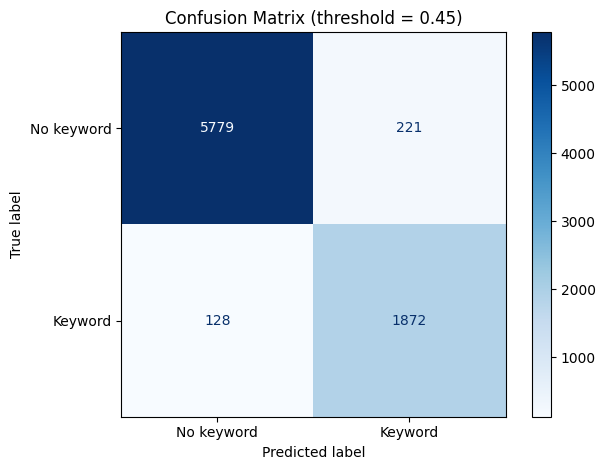

In [215]:
y_proba_lr = best_model.predict_proba(X_test)[:, 1]
manual_threshold = 0.45

thr_pred_lr = (y_proba_lr >= manual_threshold).astype(int)

cm = confusion_matrix(y_test, thr_pred_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No keyword", "Keyword"]
).plot(cmap="Blues")

plt.title(f"Confusion Matrix (threshold = {manual_threshold:.2f})")
save_plot("LR_confusion_matrix_manual_threshold.png")
plt.show()

In [216]:
plot_metrics_vs_threshold(
    y_test,
    y_pred_proba_gb,
    selected_threshold_gb,
    "Gradient Boosting",
    "GB_metrics_vs_threshold.png"
)

NameError: name 'selected_threshold_gb' is not defined

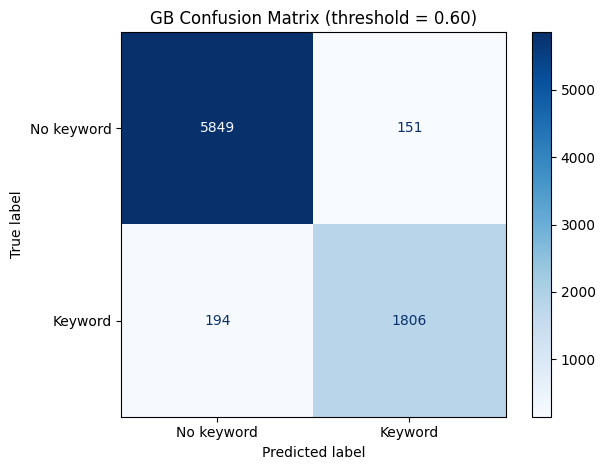

In [ ]:
thr_pred_gb = (y_pred_proba_gb >= selected_threshold_gb).astype(int)

cm = confusion_matrix(y_test, thr_pred_gb)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No keyword", "Keyword"]
).plot(cmap="Blues")

plt.title(f"GB Confusion Matrix (threshold = {selected_threshold_gb:.2f})")
save_plot("GB_confusion_matrix_threshold.png")
plt.show()

При увеличении порога возрастает precision, однако уменьшается recall. При уменьшении порога происходит обратная ситуация: модель обнаруживает больше положительных примеров, но увеличивается число ложных срабатываний. В качестве рабочего для обеих моделей был выбран threshold = 0.60, поскольку при этом значении выполняется требование recall ≥ 0.90, а среди всех таких порогов достигается максимальное значение precision. При этом F1-score также остается близким к своему максимальному значению.

### Итоговый анализ ошибок

Анализ ложных срабатываний показал, что практически все ошибки модели приходятся на набор base_neg.

На наборах confusable и podcast ложные срабатывания практически отсутствуют.

Это говорит о том, что модель уверенно отличает:

живую человеческую речь;
фонетически похожие слова.

Наибольшую сложность представляют записи, созданные тем же синтетическим голосом, что и положительные примеры. Следовательно, основным источником ошибок являются не особенности произношения слова, а сходство акустических характеристик синтетического TTS-движка

### Выбор итоговой модели

Итоговые метрики:

| Модель                    |   Accuracy |  Precision |     Recall |         F1 |    ROC-AUC |     PR-AUC |
| ------------------------- | ---------: | ---------: | ---------: | ---------: | ---------: | ---------: |
| Logistic Regression       | **0.9576** |     0.9049 | **0.9280** | **0.9163** |     0.9896 |     0.9663 |
| Gradient Boosting (tuned) |     0.95500 | **0.8988** |     0.9240 |     0.9112 | **0.9890** | **0.9668** |

Ложные срабатывания:
| Модель              | FP на base_neg |
| ------------------- | -------------: |
| Logistic Regression |     **12.67%** |
| Gradient Boosting   |     **13.73%** |

Несмотря на то что Gradient Boosting показал немного более высокие значения ROC-AUC и PR-AUC, различия с Logistic Regression оказались крайне незначительными (менее одной десятой процента). При этом Logistic Regression продемонстрировала более высокие значения Recall и F1-score, а также сопоставимый уровень ложных срабатываний на различных типах аудио.

Учитывая сопоставимое качество классификации, более высокие значения F1-score и Recall, практически одинаковый уровень ложных срабатываний, а также значительно меньшую вычислительную сложность, высокую скорость обучения и инференса, простоту настройки и интерпретации, в качестве итоговой модели была выбрана Logistic Regression.

In [ ]:
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.957625,0.904924,0.9280,0.916317,0.989660,0.966675
1,SGDClassifier (tuned),0.951875,0.905575,0.9015,0.903533,0.986980,0.956646
2,Decision Tree (tuned),0.912250,0.804695,0.8570,0.830024,0.959143,0.846166
3,Random Forest (tuned),0.943375,0.862295,0.9205,0.890447,0.983951,0.948516
4,Random Forest (tuned),0.943375,0.862295,0.9205,0.890447,0.983951,0.948516
5,Gradient Boosting (tuned),0.955000,0.898833,0.9240,0.911243,0.989850,0.966775
6,Gradient Boosting (tuned),0.955000,0.898833,0.9240,0.911243,0.989850,0.966775


## Streaming Inference

#### Лучший вычисленный порог = 0.6 Сохранение модели

In [ ]:
import joblib
import os

In [217]:
os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/logistic_regression_kws.pkl")
joblib.dump(manual_threshold, "../models/threshold.pkl")

['../models/threshold.pkl']

In [218]:
loaded_model = joblib.load("../models/logistic_regression_kws.pkl")
loaded_threshold = joblib.load("../models/threshold.pkl")

loaded_proba = loaded_model.predict_proba(X_test)[:, 1]
loaded_pred = (loaded_proba >= loaded_threshold).astype(int)

print(confusion_matrix(y_test, loaded_pred))

[[5779  221]
 [ 128 1872]]
